In [1]:
import os
import shutil

# Clean up old memmap files if they exist
for f in ['Q_matrix.dat', 'Xf_temp.dat']:
    if os.path.exists(f):
        try:
            os.remove(f)
            print(f"Removed old {f}")
        except:
            print(f"Could not remove {f}, it may be in use")

# Check you can write to current directory
test_file = "test_write.tmp"
try:
    with open(test_file, 'wb') as f:
        f.write(b'test')
    os.remove(test_file)
    print("Write permission OK")
except Exception as e:
    print(f"Write permission issue: {e}")

# Print working directory
print(f"Current working directory: {os.getcwd()}")

Write permission OK
Current working directory: c:\Users\sbhujush\Desktop\project\project_v2


In [2]:
import os
import struct
import numpy as np

# 2. Define user inputs and problem parameters

This cell defines the main inputs for the SPOD workflow.

It includes:
- grid sizes: `nx`, `ny`, `nz`
- number of time snapshots: `ntime`
- domain lengths: `Lx`, `Ly`
- binary data precision
- block size and overlap for SPOD
- file names for input and output

It also computes some derived quantities such as:
- `ns_one = nx * ny * nz`
- `ns_total = 3 * ns_one`

These values will be used throughout the notebook.

In [3]:
# =========================================================
# USER INPUTS
# =========================================================
import os

# Create temp directory if it doesn't exist
os.makedirs('_spod_temp', exist_ok=True)

infile = "flattened_data.bin"

nx = 192
ny = 192
nz = 65
ntime = 500

# Domain lengths
Lx = 3.0 * np.pi
Ly = 3.0 * np.pi

# --- Binary data type ---
q_dtype = np.dtype('<f8')   # float64 due to -fdefault-real-8

# Working precisions
w_dtype = np.float64
real_work_dtype = np.float64
complex_work_dtype = np.complex128

# Raw binary layout
records_per_timestep = 3
dof = 3

# SPOD block settings
block_size = 50
overlap = 25

# Preprocessing flags
subtract_block_mean = True
use_hann_window = True

# Physical time between consecutive snapshots
dt_snapshot = 1.0

# Reconstruction settings
n_modes_keep = 3
row_chunk = 20000

# File names
z_file = "z_coordinates.txt"

# Derived sizes
ns_one = nx * ny * nz
ns_total = records_per_timestep * ns_one

print("ns_one   =", ns_one)
print("ns_total =", ns_total)

# ---- Ensure temp directory exists ----
work_dir = os.getcwd()
print(f"\nWorking directory: {work_dir}")

temp_dir = os.path.join(work_dir, '_spod_temp')
if not os.path.exists(temp_dir):
    os.makedirs(temp_dir, exist_ok=True)
    print(f"Created temp directory: {temp_dir}")

q_memmap_file = os.path.join(temp_dir, "Q_matrix.dat")
temp_xf_file = os.path.join(temp_dir, "Xf_temp.dat")

print(f"Q memmap file: {q_memmap_file}")
print(f"Temp Xf file:  {temp_xf_file}")

# ---- File-size sanity check for precision ----
if os.path.exists(infile):
    nbytes = os.path.getsize(infile)
    exp_f32 = ns_total * ntime * 4
    exp_f64 = ns_total * ntime * 8
    print(f"\n{infile} size: {nbytes:,} bytes")
    print(f"  expected float32: {exp_f32:,}")
    print(f"  expected float64: {exp_f64:,}")
    if nbytes == exp_f32:
        print("  ==> float32 confirmed.")
    elif nbytes == exp_f64:
        print("  ==> float64 detected.")
    else:
        print("  !! WARNING: size matches neither precision. "
              "Check NTIME, endianness, or records_per_timestep.")

ns_one   = 2396160
ns_total = 7188480

Working directory: c:\Users\sbhujush\Desktop\project\project_v2
Q memmap file: c:\Users\sbhujush\Desktop\project\project_v2\_spod_temp\Q_matrix.dat
Temp Xf file:  c:\Users\sbhujush\Desktop\project\project_v2\_spod_temp\Xf_temp.dat

flattened_data.bin size: 28,753,920,000 bytes
  expected float32: 14,376,960,000
  expected float64: 28,753,920,000
  ==> float64 detected.


# 3. Define the spatial weight-vector function

This cell defines a function that builds the 1D diagonal weight vector `W_1D`.

The purpose of this vector is to represent the diagonal entries of the spatial weight matrix `W` without explicitly building the full 2D matrix.

The function:
- reads the nonuniform vertical coordinates from file
- computes nodal control-volume weights
- accounts for periodic uniform spacing in `x` and `y`
- expands the weights for all three velocity components `[U, V, W]`

The output of the function is a 1D array of length `3 * nx * ny * nz`.

In [4]:
def build_W_1D(Lx, Ly, Nx, Ny, Nz, filename='z_coordinates.txt',
               dof=3, dtype=np.float64):
    if Nz < 2:
        raise ValueError("Nz must be at least 2.")

    try:
        z_coords = np.loadtxt(filename).astype(dtype)
    except FileNotFoundError:
        raise FileNotFoundError(f"Could not find '{filename}'.")

    if z_coords.size != Nz:
        raise ValueError(
            f"Grid mismatch: expected Nz={Nz}, file has {z_coords.size} points."
        )
    if not np.all(np.diff(z_coords) > 0):
        raise ValueError("z_coordinates.txt must be strictly increasing.")

    dx = Lx / Nx
    dy = Ly / Ny

    # --- Vectorized non-uniform trapezoidal weights in z ---
    dz = np.empty(Nz, dtype=dtype)
    dz[0]    = 0.5 * (z_coords[1]  - z_coords[0])
    dz[-1]   = 0.5 * (z_coords[-1] - z_coords[-2])
    dz[1:-1] = 0.5 * (z_coords[2:] - z_coords[:-2])

    # Broadcast (Nz, Ny, Nx) with k slowest, i fastest — matches Fortran
    # stream order (((·,I),J),K): I fastest, J middle, K slowest.
    node_vol_3d = (dx * dy * dz)[:, None, None] * np.ones((Nz, Ny, Nx), dtype=dtype)
    W_diag = node_vol_3d.ravel(order='C')   # C-order => k*Ny*Nx + j*Nx + i

    # --- Consistency check ---
    calc = W_diag.sum()
    true_vol = Lx * Ly * (z_coords[-1] - z_coords[0])
    rel_err = abs(calc - true_vol) / true_vol
    print(f"Total weight sum : {calc:.12e}")
    print(f"Actual volume    : {true_vol:.12e}")
    print(f"Relative error   : {rel_err:.3e}")
    if rel_err > 1e-10:
        print("WARNING: volumes do not match — check grid inputs.")
    else:
        print("SUCCESS: weight matrix matches physical domain volume.")

    # Tile for [U; V; W] — same spatial weight for each velocity component
    W_1D = np.tile(W_diag, dof)
    return W_1D

# 4. Build and inspect the weight vector

This cell calls the weight-building function and creates `W_1D`.

The result is a 1D array containing one spatial weight for each row of the snapshot matrix.

This cell also prints:
- the total size of `W_1D`
- a few sample values
- a consistency check comparing the sum of the weights to the physical domain volume

In [5]:
W_1D = build_W_1D(
    Lx=Lx,
    Ly=Ly,
    Nx=nx,
    Ny=ny,
    Nz=nz,
    filename=z_file,
    dof=dof,
    dtype=w_dtype,
)

print("W_1D shape =", W_1D.shape)
print("First 10 weights =", W_1D[:10])

Total weight sum : 8.882643960980e+01
Actual volume    : 8.882643960980e+01
Relative error   : 0.000e+00
SUCCESS: weight matrix matches physical domain volume.
W_1D shape = (7188480,)
First 10 weights = [8.71934043e-07 8.71934043e-07 8.71934043e-07 8.71934043e-07
 8.71934043e-07 8.71934043e-07 8.71934043e-07 8.71934043e-07
 8.71934043e-07 8.71934043e-07]


# 5. Define the function for reading one Fortran stream binary block

The original DNS data was written by Fortran using unformatted stream access.

Because the file was written with `ACCESS='STREAM'`, it does not contain Fortran record markers.  
Instead, the binary file is just a continuous stream of raw bytes.

This function reads one raw block at a time by:
- computing how many bytes correspond to one field
- reading exactly that many bytes from the file
- converting the bytes into a NumPy array

This function is the low-level reader used to rebuild the full snapshot matrix from the stream binary file.

In [6]:
def read_stream_record(f, ns_one, dtype):
    """
    Read one raw block from a Fortran STREAM unformatted file.

    Since ACCESS='STREAM' was used in Fortran, there are no record markers.
    We therefore read exactly ns_one values each time.
    """
    nbytes = ns_one * np.dtype(dtype).itemsize
    data = f.read(nbytes)

    if not data:
        return None

    if len(data) < nbytes:
        raise EOFError(f"Unexpected EOF: expected {nbytes} bytes, got {len(data)}")

    return np.frombuffer(data, dtype=dtype).copy()

# 6. Define the function that builds the full time-domain matrix `Q`

This cell defines the function that converts the raw Fortran binary file into the full 2D snapshot matrix `Q`.

In this matrix:
- rows = spatial DOFs
- columns = time snapshots

Each column is ordered as:
- all `U`
- then all `V`
- then all `W`

The matrix is written to disk as a memmap file.

In [7]:
def build_Q_memmap(
    infile,
    nx,
    ny,
    nz,
    ntime,
    dtype=np.float32,
    records_per_timestep=3,
    out_memmap="Q_matrix.dat",
):
    ns_one = nx * ny * nz
    ns_total = records_per_timestep * ns_one

    Q = np.memmap(out_memmap, dtype=dtype, mode="w+", shape=(ns_total, ntime))

    with open(infile, "rb") as f:
        for t in range(ntime):
            blocks = []
            for r in range(records_per_timestep):
                rec = read_stream_record(f, ns_one, dtype)
                if rec is None:
                    raise EOFError(
                        f"Unexpected EOF at timestep {t + 1}, record {r + 1}"
                    )
                if rec.size != ns_one:
                    raise ValueError(
                        f"Record size mismatch at timestep {t + 1}, record {r + 1}: "
                        f"got {rec.size}, expected {ns_one}"
                    )
                blocks.append(rec)
            Q[:, t] = np.concatenate(blocks)

        # Verify we exhausted the file exactly
        extra = f.read(1)
        if extra:
            raise ValueError("Trailing bytes after ntime snapshots — "
                             "ntime or records_per_timestep may be wrong.")

    Q.flush()

    # --- Sanity snapshot of the first time step ---
    u0 = Q[:ns_one, 0]
    v0 = Q[ns_one:2*ns_one, 0]
    w0 = Q[2*ns_one:3*ns_one, 0]
    print(f"t=0 U range: [{u0.min():.4g}, {u0.max():.4g}], mean {u0.mean():.4g}")
    print(f"t=0 V range: [{v0.min():.4g}, {v0.max():.4g}], mean {v0.mean():.4g}")
    print(f"t=0 W range: [{w0.min():.4g}, {w0.max():.4g}], mean {w0.mean():.4g}")
    if not np.all(np.isfinite(u0[:1000])):
        raise ValueError("Non-finite values in U at t=0 — likely wrong "
                         "precision or endianness.")
    return Q

# 7. Build and inspect the full time-domain matrix `Q`

This cell reads the original Fortran binary file and reorganizes it into the full time-domain snapshot matrix `Q`.

The result is stored on disk as a memmap array.

At this stage, the raw binary has been converted into a structured 2D matrix form suitable for SPOD.

In [8]:
Q = build_Q_memmap(
    infile=infile,
    nx=nx,
    ny=ny,
    nz=nz,
    ntime=ntime,
    dtype=q_dtype,
    records_per_timestep=records_per_timestep,
    out_memmap=q_memmap_file,
)

print("Q stored in:", q_memmap_file)
print("Q shape =", Q.shape)
print("Q dtype =", Q.dtype)

t=0 U range: [-0.0626, 1.122], mean 0.6447
t=0 V range: [-0.2624, 0.2929], mean 0.0003372
t=0 W range: [-0.2038, 0.2478], mean 0.0002004
Q stored in: c:\Users\sbhujush\Desktop\project\project_v2\_spod_temp\Q_matrix.dat
Q shape = (7188480, 500)
Q dtype = float64


# 8. Re-open the full time-domain matrix from disk

This cell re-opens the memmap file containing `Q`.

This is useful in notebook workflows, because later cells can access `Q` directly from disk without rebuilding it again from the raw binary file.

In [9]:
Q = np.memmap(q_memmap_file, dtype=q_dtype, mode="r", shape=(ns_total, ntime))
print(Q.shape)

(7188480, 500)


# 9. Define the block-start function

SPOD divides the time series into overlapping blocks.

This cell defines the function that computes the valid starting indices of all complete blocks based on:
- total number of snapshots
- block size
- overlap

In [10]:
def get_block_starts(ntime, block_size, overlap):
    if block_size <= 1:
        raise ValueError("block_size must be at least 2.")
    if overlap < 0:
        raise ValueError("overlap must be non-negative.")
    if overlap >= block_size:
        raise ValueError("overlap must be smaller than block_size.")
    if block_size > ntime:
        raise ValueError("block_size cannot exceed ntime.")

    step = block_size - overlap
    starts = list(range(0, ntime - block_size + 1, step))
    return starts

# 10. Compute and inspect the SPOD block layout

This cell computes:
- the list of block starting indices
- the number of blocks
- the number of frequencies returned by the real FFT

These values determine the structure of the later SPOD matrices.

In [11]:
starts = get_block_starts(ntime, block_size, overlap)
nblk = len(starts)
nfreq = block_size // 2 + 1

print("starts =", starts)
print("nblk   =", nblk)
print("nfreq  =", nfreq)

starts = [0, 25, 50, 75, 100, 125, 150, 175, 200, 225, 250, 275, 300, 325, 350, 375, 400, 425, 450]
nblk   = 19
nfreq  = 26


# 11. Extract one time block from `Q`

This cell selects one block from the full time-domain matrix.

The block has shape:
- rows = spatial DOFs
- columns = time samples within the block

At this point, the data is still in the physical time domain.

In [12]:
m = 0
start = starts[m]
stop = start + block_size

Q_block = np.asarray(Q[:, start:stop], dtype=real_work_dtype).copy()

print("Block index :", m)
print("start, stop :", start, stop)
print("Q_block shape =", Q_block.shape)

Block index : 0
start, stop : 0 50
Q_block shape = (7188480, 50)


# 12. Subtract the block mean

This cell optionally subtracts the time mean from each row of the selected block.

This converts the block into fluctuation data, which is usually preferred before FFT and SPOD.

In [13]:
Q_block_centered = Q_block.copy()

if subtract_block_mean:
    Q_block_centered = Q_block_centered - Q_block_centered.mean(axis=1, keepdims=True)

print("Centered block shape =", Q_block_centered.shape)

Centered block shape = (7188480, 50)


# 13. Create the temporal window

This cell creates the time-window function used before FFT.

If `use_hann_window` is true, a Hann window is used.
Otherwise, an all-ones window is used.

The purpose is to reduce spectral leakage.

In [14]:
if use_hann_window:
    window = np.hanning(block_size).astype(real_work_dtype)
else:
    window = np.ones(block_size, dtype=real_work_dtype)

print("window shape =", window.shape)
print(window[:10])

window shape = (50,)
[0.         0.00410499 0.01635257 0.03654162 0.06434065 0.09929319
 0.14082532 0.1882551  0.24080372 0.29760833]


# 14. Apply the window to one block

This cell multiplies every row of the block by the same temporal window.

This tapers the signal at the beginning and end of the block before FFT.

In [15]:
Q_block_windowed = Q_block_centered * window[np.newaxis, :]
print("Q_block_windowed shape =", Q_block_windowed.shape)

Q_block_windowed shape = (7188480, 50)


# 15. Compute the FFT of one block

This cell applies the FFT along the time direction of the selected block.

The output is now in the frequency domain.

Its shape is:
- rows = spatial DOFs
- columns = retained frequencies

In [16]:
Qhat_block = np.fft.rfft(Q_block_windowed, axis=1).astype(complex_work_dtype)

print("Qhat_block shape =", Qhat_block.shape)
print("Expected nfreq   =", nfreq)

Qhat_block shape = (7188480, 26)
Expected nfreq   = 26


# 16. Inspect one frequency vector from one block

This cell extracts one frequency column from the FFT of one block.

The result is a complex vector of length equal to the number of spatial DOFs.

This represents the flow field at one selected frequency for one selected block.

In [17]:
j = 0
freq_vector = Qhat_block[:, j]

print("freq index =", j)
print("freq_vector shape =", freq_vector.shape)
print("first 5 entries =", freq_vector[:5])

freq index = 0
freq_vector shape = (7188480,)
first 5 entries = [ 0.00062408+0.j  0.00024268+0.j -0.00014804+0.j -0.00053307+0.j
 -0.00089762+0.j]


# 17. Define the function that builds one frequency-wise matrix `X(f)`

For one chosen frequency index, this function:
- loops over all blocks
- extracts the block from `Q`
- optionally subtracts the block mean
- applies the temporal window
- computes the FFT
- stores the selected frequency into the corresponding block column

The result is the SPOD matrix `X(f)` with shape:
- rows = spatial DOFs
- columns = blocks

In [18]:
def build_single_frequency_matrix(
    q_memmap_file,
    shape_q,
    starts,
    block_size,
    freq_index,
    q_dtype=np.float32,
    real_dtype=np.float64,
    complex_dtype=np.complex128,
    subtract_block_mean=True,
    use_hann_window=True,
    dt_snapshot=1.0,
    temp_xf_file="Xf_temp.dat",
):
    import gc
    ns, ntime = shape_q
    nblk = len(starts)

    # --- Windows-safe memmap recreation ---
    parent = os.path.dirname(temp_xf_file)
    if parent:
        os.makedirs(parent, exist_ok=True)
    gc.collect()                           # release any prior memmap handles
    if os.path.exists(temp_xf_file):
        try:
            os.remove(temp_xf_file)
        except PermissionError:
            gc.collect()
            os.remove(temp_xf_file)       # one retry after GC

    Q  = np.memmap(q_memmap_file, dtype=q_dtype, mode="r", shape=(ns, ntime))
    Xf = np.memmap(temp_xf_file, dtype=complex_dtype, mode="w+", shape=(ns, nblk))

    if use_hann_window:
        window = np.hanning(block_size).astype(real_dtype)
    else:
        window = np.ones(block_size, dtype=real_dtype)

    window_scale = np.sqrt(dt_snapshot / np.sum(window**2))

    for m, start in enumerate(starts):
        stop = start + block_size
        Q_block = np.asarray(Q[:, start:stop], dtype=real_dtype).copy()  # <-- ADD .copy()

        if subtract_block_mean:
            Q_block -= Q_block.mean(axis=1, keepdims=True)

        Q_block *= window[np.newaxis, :]
        Qhat_block = np.fft.rfft(Q_block, axis=1).astype(complex_dtype)
        Qhat_block *= window_scale

        Xf[:, m] = Qhat_block[:, freq_index]

    Xf.flush()
    return Xf

# 18. Build and inspect one frequency-wise matrix `X(f)`

This cell constructs `X(f)` for one selected frequency.

This matrix contains:
- rows = spatial DOFs
- columns = blocks

This is the matrix that will be used to build the reduced SPOD matrix at that frequency.

In [19]:
j = 0

Xf = build_single_frequency_matrix(
    q_memmap_file=q_memmap_file,
    shape_q=(ns_total, ntime),
    starts=starts,
    block_size=block_size,
    freq_index=j,
    q_dtype=q_dtype,
    real_dtype=real_work_dtype,
    complex_dtype=complex_work_dtype,
    subtract_block_mean=subtract_block_mean,
    use_hann_window=use_hann_window,
    dt_snapshot=dt_snapshot,                       # <-- NEW
    temp_xf_file=temp_xf_file,
)

print("Xf shape =", Xf.shape)
print("Xf dtype =", Xf.dtype)

Xf shape = (7188480, 19)
Xf dtype = complex128


# 19. Define the reduced SPOD matrix function

This function computes the reduced matrix

\[
R(f) = X(f)^* W X(f)
\]

without explicitly building the full diagonal matrix `W`.

Instead, it uses the 1D weight vector `W_1D` and weighted row scaling.

In [20]:
def compute_reduced_matrix_from_Xf(
    xf_memmap_file,
    shape_xf,
    W_1D,
    complex_dtype=np.complex128,
    out_dtype=np.complex128,
    row_chunk=20000,
):
    """
    Builds the reduced cross-spectral density matrix

        S(f) = (1/M) * X(f)^H * W * X(f)

    whose eigenvalues are the physical SPOD modal energies (PSD units
    when X has been window/Δt scaled upstream).
    """
    ns, nblk = shape_xf

    if W_1D.shape[0] != ns:
        raise ValueError(
            f"W_1D length mismatch: got {W_1D.shape[0]}, expected {ns}"
        )

    Xf = np.memmap(xf_memmap_file, dtype=complex_dtype, mode="r", shape=(ns, nblk))
    Rf = np.zeros((nblk, nblk), dtype=out_dtype)

    for i0 in range(0, ns, row_chunk):
        i1 = min(i0 + row_chunk, ns)
        X_chunk = np.asarray(Xf[i0:i1, :], dtype=out_dtype)
        W_chunk = np.asarray(W_1D[i0:i1], dtype=np.float64)
        WX_chunk = W_chunk[:, np.newaxis] * X_chunk
        Rf += X_chunk.conj().T @ WX_chunk

    Rf /= nblk                       # <-- THE FIX: divide by number of blocks

    # Hermitian cleanup: zero out tiny non-Hermitian roundoff
    Rf = 0.5 * (Rf + Rf.conj().T)
    return Rf

# 20. Compute and inspect one reduced matrix `R(f)`

This cell computes the reduced SPOD matrix for one frequency.

The output is a small matrix of size:
- number of blocks × number of blocks

This is the matrix on which the POD eigenvalue decomposition is performed.

In [21]:
Rf = compute_reduced_matrix_from_Xf(
    xf_memmap_file=temp_xf_file,
    shape_xf=(ns_total, nblk),
    W_1D=W_1D,
    complex_dtype=complex_work_dtype,
    out_dtype=complex_work_dtype,
    row_chunk=row_chunk,
)

print("Rf shape =", Rf.shape)
print("Rf[0:3,0:3] =\n", Rf[:3, :3])

Rf shape = (19, 19)
Rf[0:3,0:3] =
 [[ 0.07505758+0.j -0.05583796+0.j  0.02493405+0.j]
 [-0.05583796+0.j  0.08116324+0.j -0.06037845+0.j]
 [ 0.02493405+0.j -0.06037845+0.j  0.08415259+0.j]]


# 21. Define the reduced eigenproblem solver

This function solves the Hermitian eigenvalue problem for the reduced matrix.

It:
- computes eigenvalues and eigenvectors
- sorts the eigenvalues in descending order
- reorders the eigenvectors
- clips tiny negative roundoff values to zero

In [22]:
def solve_reduced_eigenproblem(Rf, tol=1e-12):
    eigvals, eigvecs = np.linalg.eigh(Rf)

    idx = np.argsort(eigvals.real)[::-1]
    eigvals = eigvals[idx].real
    eigvecs = eigvecs[:, idx]

    eigvals[np.abs(eigvals) < tol] = 0.0
    eigvals[eigvals < 0.0] = 0.0

    return eigvals, eigvecs

# 22. Solve the reduced eigenproblem for one frequency

This cell computes the eigenvalues and reduced eigenvectors of the reduced SPOD matrix.

The eigenvalues are the modal energies.
The eigenvectors are the reduced block-space coefficients used to reconstruct the actual spatial modes.

In [23]:
eigvals, eigvecs = solve_reduced_eigenproblem(Rf)

print("eigvals shape =", eigvals.shape)
print("eigvecs shape =", eigvecs.shape)
print("first 10 eigvals =", eigvals[:10])

eigvals shape = (19,)
eigvecs shape = (19, 19)
first 10 eigvals = [0.35887678 0.29728043 0.21027619 0.19708091 0.17286677 0.13684515
 0.07507018 0.04285254 0.03520995 0.02844567]


# 23. Define the spatial mode reconstruction function

This function reconstructs the actual spatial SPOD modes using:

$$
\Phi(f) = X(f)\Psi(f)\,(N_{blk}\Lambda)^{-1/2}
$$

It takes:
- the frequency-wise matrix `X(f)`
- the reduced eigenvectors
- the eigenvalues

and returns the spatial modes stored on disk.

In [24]:
def reconstruct_spod_modes(
    xf_memmap_file,
    shape_xf,
    eigvals,
    eigvecs,
    nblk,
    W_1D=None,                                    # <-- NEW (for verification)
    n_modes_keep=None,
    complex_dtype=np.complex128,
    out_dtype=np.complex128,
    row_chunk=20000,
    mode_file="Phi_freq_0000.dat",
    tol=1e-12,
    verify_orthonormality=True,                   # <-- NEW
):
    ns, nblk_check = shape_xf
    if nblk_check != nblk:
        raise ValueError("shape_xf second dimension does not match nblk.")

    if n_modes_keep is None:
        n_modes_keep = nblk
    n_modes_keep = min(n_modes_keep, nblk)

    valid = eigvals[:n_modes_keep] > tol
    kept_indices = np.where(valid)[0]
    n_keep_valid = kept_indices.size

    import gc
    parent = os.path.dirname(mode_file)
    if parent:
        os.makedirs(parent, exist_ok=True)
    gc.collect()
    if os.path.exists(mode_file):
        try:
            os.remove(mode_file)
        except PermissionError:
            gc.collect()
            os.remove(mode_file)

    Xf = np.memmap(xf_memmap_file, dtype=complex_dtype, mode="r", shape=(ns, nblk))
    Phi = np.memmap(mode_file, dtype=out_dtype, mode="w+",
                    shape=(ns, max(n_keep_valid, 1)))
    Phi[:] = 0.0 + 0.0j

    if n_keep_valid == 0:
        Phi.flush()
        return Phi, kept_indices

    lam_keep = eigvals[kept_indices]
    psi_keep = eigvecs[:, kept_indices]

    # Phi = X Psi / sqrt(M * Lambda)  -- gives Phi^H W Phi = I
    coeff = psi_keep / np.sqrt(nblk * lam_keep)[np.newaxis, :]

    for i0 in range(0, ns, row_chunk):
        i1 = min(i0 + row_chunk, ns)
        X_chunk = np.asarray(Xf[i0:i1, :], dtype=out_dtype)
        Phi[i0:i1, :] = X_chunk @ coeff

    Phi.flush()

    # --- Orthonormality verification ---
    if verify_orthonormality and W_1D is not None and n_keep_valid > 0:
        # Chunked computation of G = Phi^H W Phi
        G = np.zeros((n_keep_valid, n_keep_valid), dtype=out_dtype)
        for i0 in range(0, ns, row_chunk):
            i1 = min(i0 + row_chunk, ns)
            P_chunk = np.asarray(Phi[i0:i1, :], dtype=out_dtype)
            W_chunk = np.asarray(W_1D[i0:i1], dtype=np.float64)
            G += P_chunk.conj().T @ (W_chunk[:, None] * P_chunk)
        err = np.max(np.abs(G - np.eye(n_keep_valid)))
        print(f"  Orthonormality max |Phi^H W Phi - I| = {err:.3e}")

    return Phi, kept_indices

# 24. Reconstruct and inspect the spatial modes for one frequency

This cell reconstructs the actual SPOD modes for the selected frequency.

Each column of `Phi` is one spatial SPOD mode.
Only the first few requested modes are kept.

In [25]:
Phi, kept_idx = reconstruct_spod_modes(
    xf_memmap_file=temp_xf_file,
    shape_xf=(ns_total, nblk),
    eigvals=eigvals,
    eigvecs=eigvecs,
    nblk=nblk,
    W_1D=W_1D,                                    # <-- NEW
    n_modes_keep=n_modes_keep,
    complex_dtype=complex_work_dtype,
    out_dtype=complex_work_dtype,
    row_chunk=row_chunk,
    mode_file="Phi_freq_0000.dat",
)

print("Phi shape =", Phi.shape)
print("kept mode indices =", kept_idx)

  Orthonormality max |Phi^H W Phi - I| = 2.331e-15
Phi shape = (7188480, 3)
kept mode indices = [0 1 2]


# 25. Define a wrapper that runs the full SPOD workflow for one frequency

This function combines the main SPOD steps for a single frequency:

1. build `X(f)`
2. compute `R(f)`
3. solve the reduced eigenproblem
4. reconstruct the spatial modes

This is convenient for debugging or studying one frequency at a time.

In [26]:
def run_one_frequency_spod(
    freq_index,
    q_memmap_file,
    shape_q,
    W_1D,
    starts,
    block_size,
    q_dtype=np.float32,
    real_dtype=np.float64,
    complex_dtype=np.complex128,
    subtract_block_mean=True,
    use_hann_window=True,
    dt_snapshot=1.0,                              # <-- NEW
    row_chunk=20000,
    n_modes_keep=3,
    temp_xf_file="Xf_temp.dat",
    mode_file=None,
    verify_orthonormality=True,
):
    ns, ntime = shape_q
    nblk = len(starts)

    if mode_file is None:
        mode_file = f"Phi_freq_{freq_index:04d}.dat"

    Xf = build_single_frequency_matrix(
        q_memmap_file=q_memmap_file,
        shape_q=shape_q,
        starts=starts,
        block_size=block_size,
        freq_index=freq_index,
        q_dtype=q_dtype,
        real_dtype=real_dtype,
        complex_dtype=complex_dtype,
        subtract_block_mean=subtract_block_mean,
        use_hann_window=use_hann_window,
        dt_snapshot=dt_snapshot,                  # <-- NEW
        temp_xf_file=temp_xf_file,
    )

    Rf = compute_reduced_matrix_from_Xf(
        xf_memmap_file=temp_xf_file,
        shape_xf=(ns, nblk),
        W_1D=W_1D,
        complex_dtype=complex_dtype,
        out_dtype=complex_dtype,
        row_chunk=row_chunk,
    )

    eigvals, eigvecs = solve_reduced_eigenproblem(Rf)

    Phi, kept_idx = reconstruct_spod_modes(
        xf_memmap_file=temp_xf_file,
        shape_xf=(ns, nblk),
        eigvals=eigvals,
        eigvecs=eigvecs,
        nblk=nblk,
        W_1D=W_1D,                                # <-- NEW
        n_modes_keep=n_modes_keep,
        complex_dtype=complex_dtype,
        out_dtype=complex_dtype,
        row_chunk=row_chunk,
        mode_file=mode_file,
        verify_orthonormality=verify_orthonormality,
    )

    return Xf, Rf, eigvals, eigvecs, Phi, kept_idx

# 26. Run the full SPOD workflow for one selected frequency

This cell executes the complete SPOD pipeline for one frequency index.

It returns:
- the frequency-wise matrix `X(f)`
- the reduced matrix `R(f)`
- eigenvalues
- reduced eigenvectors
- reconstructed spatial modes

This is the best cell to test before looping over all frequencies.

In [27]:
# Release globals from the step-by-step cells so Cell 51 can recreate the memmap files
import gc
for _name in ('Xf', 'Rf', 'Phi', 'Q_block', 'Q_block_centered',
              'Q_block_windowed', 'Qhat_block', 'freq_vector'):
    globals().pop(_name, None)
gc.collect()

0

In [28]:
freq_index = 0

Xf, Rf, eigvals, eigvecs, Phi, kept_idx = run_one_frequency_spod(
    freq_index=freq_index,
    q_memmap_file=q_memmap_file,
    shape_q=(ns_total, ntime),
    W_1D=W_1D,
    starts=starts,
    block_size=block_size,
    q_dtype=q_dtype,
    real_dtype=real_work_dtype,
    complex_dtype=complex_work_dtype,
    subtract_block_mean=subtract_block_mean,
    use_hann_window=use_hann_window,
    dt_snapshot=dt_snapshot,                      # <-- NEW
    row_chunk=row_chunk,
    n_modes_keep=n_modes_keep,
    temp_xf_file=temp_xf_file,
    mode_file=f"Phi_freq_{freq_index:04d}.dat",
)

print("Finished frequency", freq_index)
print("Rf shape =", Rf.shape)
print("Phi shape =", Phi.shape)
print("First few eigvals =", eigvals[:10])

  Orthonormality max |Phi^H W Phi - I| = 2.331e-15
Finished frequency 0
Rf shape = (19, 19)
Phi shape = (7188480, 3)
First few eigvals = [0.35887678 0.29728043 0.21027619 0.19708091 0.17286677 0.13684515
 0.07507018 0.04285254 0.03520995 0.02844567]


# 27. Optional loop over all frequencies

This cell shows how to repeat the full one-frequency SPOD workflow for every retained frequency.

This should only be done after the single-frequency pipeline has been tested and verified.

In [29]:
# Physical frequency axis (cycles per time unit; multiply by 2*pi for angular)
freq_axis = np.fft.rfftfreq(block_size, d=dt_snapshot)
all_eigvals = np.zeros((nfreq, nblk), dtype=real_work_dtype)

import gc

for freq_index in range(nfreq):
    # Release memmaps from the previous iteration to avoid Windows file locking
    for _n in ('Xf', 'Rf', 'eigvals', 'eigvecs', 'Phi', 'kept_idx'):
        globals().pop(_n, None)
    gc.collect()
    
    print(f"\nRunning frequency {freq_index:3d} (f = {freq_axis[freq_index]:.4g})")
    Xf, Rf, eigvals, eigvecs, Phi, kept_idx = run_one_frequency_spod(
        freq_index=freq_index,
        q_memmap_file=q_memmap_file,
        shape_q=(ns_total, ntime),
        W_1D=W_1D,
        starts=starts,
        block_size=block_size,
        q_dtype=q_dtype,
        real_dtype=real_work_dtype,
        complex_dtype=complex_work_dtype,
        subtract_block_mean=subtract_block_mean,
        use_hann_window=use_hann_window,
        dt_snapshot=dt_snapshot,
        row_chunk=row_chunk,
        n_modes_keep=n_modes_keep,
        temp_xf_file=temp_xf_file,
        mode_file=f"Phi_freq_{freq_index:04d}.dat",
        verify_orthonormality=(freq_index == 0),  # just check once to save time
    )
    all_eigvals[freq_index, :] = eigvals

# Save eigenvalue spectrum for later plotting
np.savez("spod_eigvals.npz",
         freq_axis=freq_axis,
         eigvals=all_eigvals,
         block_size=block_size,
         overlap=overlap,
         nblk=nblk,
         dt_snapshot=dt_snapshot)

print("\nDone. Eigenvalues saved to spod_eigvals.npz")
print("all_eigvals shape =", all_eigvals.shape, "(nfreq, nblk)")


Running frequency   0 (f = 0)
  Orthonormality max |Phi^H W Phi - I| = 2.331e-15

Running frequency   1 (f = 0.02)

Running frequency   2 (f = 0.04)

Running frequency   3 (f = 0.06)

Running frequency   4 (f = 0.08)

Running frequency   5 (f = 0.1)

Running frequency   6 (f = 0.12)

Running frequency   7 (f = 0.14)

Running frequency   8 (f = 0.16)

Running frequency   9 (f = 0.18)

Running frequency  10 (f = 0.2)

Running frequency  11 (f = 0.22)

Running frequency  12 (f = 0.24)

Running frequency  13 (f = 0.26)

Running frequency  14 (f = 0.28)

Running frequency  15 (f = 0.3)

Running frequency  16 (f = 0.32)

Running frequency  17 (f = 0.34)

Running frequency  18 (f = 0.36)

Running frequency  19 (f = 0.38)

Running frequency  20 (f = 0.4)

Running frequency  21 (f = 0.42)

Running frequency  22 (f = 0.44)

Running frequency  23 (f = 0.46)

Running frequency  24 (f = 0.48)

Running frequency  25 (f = 0.5)

Done. Eigenvalues saved to spod_eigvals.npz
all_eigvals shape = (26, 19)

# Analysis Step 1 — Load and sanity-check the saved SPOD results

This cell opens `spod_eigvals.npz` and validates the stored eigenvalue spectrum before any plotting.

It will:
- Load the `.npz` and pull out `freq_axis`, `all_eigvals`, and the stored metadata (`block_size`, `overlap`, `nblk`, `dt_snapshot`).
- Confirm the array shape is `(nfreq, nblk) = (26, 7)`.
- Check for NaN / Inf values and for any negative eigenvalues (these should have been clipped to zero during the pipeline — any that remain would indicate a problem).
- Confirm the eigenvalues at each frequency are in descending order.
- Print a short header summary so the rest of the analysis has a known-good starting point.

No plotting yet — this step is purely about confirming the data we're about to analyze is clean.

In [30]:
# =========================================================
# Analysis Step 1: Load and sanity-check spod_eigvals.npz
# =========================================================
import numpy as np
import os

# Analysis-wide imports and plotting defaults (used by all later cells)
import matplotlib.pyplot as plt
plt.rcParams.update({
    "figure.dpi":       110,
    "savefig.dpi":      200,
    "font.size":        11,
    "axes.grid":        True,
    "grid.alpha":       0.3,
    "axes.labelsize":   12,
    "axes.titlesize":   12,
    "legend.fontsize":  10,
    "lines.linewidth":  1.6,
})

# ---- Load the eigenvalue archive ----
npz_file = "spod_eigvals.npz"
if not os.path.exists(npz_file):
    raise FileNotFoundError(f"Could not find {npz_file} in {os.getcwd()}")

data        = np.load(npz_file)
freq_axis   = data["freq_axis"]            # shape (nfreq,)
all_eigvals = data["eigvals"]              # shape (nfreq, nblk)
bs_saved    = int(data["block_size"])
ov_saved    = int(data["overlap"])
nblk_saved  = int(data["nblk"])
dt_saved    = float(data["dt_snapshot"])

nfreq_loaded, nblk_loaded = all_eigvals.shape

# ---- Shape checks ----
assert freq_axis.shape == (nfreq_loaded,), "freq_axis length mismatch"
assert nblk_loaded == nblk_saved, "stored nblk does not match eigvals shape"
print(f"Loaded: {npz_file}")
print(f"  all_eigvals shape = {all_eigvals.shape}  (nfreq, nblk)")
print(f"  freq_axis  shape = {freq_axis.shape}")
print(f"  block_size = {bs_saved}, overlap = {ov_saved}, "
      f"nblk = {nblk_saved}, dt_snapshot = {dt_saved}")

# ---- Finiteness and sign checks ----
n_nan = np.isnan(all_eigvals).sum()
n_inf = np.isinf(all_eigvals).sum()
n_neg = (all_eigvals < 0).sum()

print("\nFiniteness / sign checks:")
print(f"  NaN count        : {n_nan}")
print(f"  Inf count        : {n_inf}")
print(f"  Negative count   : {n_neg}  (should be 0 after pipeline clipping)")
if n_nan or n_inf or n_neg:
    print("  !! WARNING: flagged values present — investigate before proceeding.")
else:
    print("  All eigenvalues are finite and non-negative. ")

# ---- Descending-order check (per frequency) ----
# all_eigvals[f, 0] should be the largest; all_eigvals[f, -1] the smallest.
# Allow for tiny floating roundoff (1e-14 tolerance).
diffs = np.diff(all_eigvals, axis=1)
bad_rows = np.where((diffs > 1e-14).any(axis=1))[0]
print(f"\nDescending-order check:")
if bad_rows.size == 0:
    print("  Every frequency has eigenvalues sorted in descending order. ")
else:
    print(f"  !! {bad_rows.size} frequencies are NOT sorted descending: "
          f"indices {bad_rows.tolist()}")

# ---- Summary numbers ----
print("\nSpectrum quick stats:")
print(f"  Frequency range   : [{freq_axis[0]:.4f}, {freq_axis[-1]:.4f}]  "
      f"(Δf = {freq_axis[1] - freq_axis[0]:.4f})")
print(f"  Max eigenvalue    : {all_eigvals.max():.6e}  "
      f"at (f_idx={np.unravel_index(all_eigvals.argmax(), all_eigvals.shape)[0]}, "
      f"mode={np.unravel_index(all_eigvals.argmax(), all_eigvals.shape)[1]})")
print(f"  Min eigenvalue    : {all_eigvals.min():.6e}")
print(f"  Total summed energy (Σ λ over all f, k): {all_eigvals.sum():.6e}")

Loaded: spod_eigvals.npz
  all_eigvals shape = (26, 19)  (nfreq, nblk)
  freq_axis  shape = (26,)
  block_size = 50, overlap = 25, nblk = 19, dt_snapshot = 1.0

Finiteness / sign checks:
  NaN count        : 0
  Inf count        : 0
  Negative count   : 0  (should be 0 after pipeline clipping)
  All eigenvalues are finite and non-negative. 

Descending-order check:
  Every frequency has eigenvalues sorted in descending order. 

Spectrum quick stats:
  Frequency range   : [0.0000, 0.5000]  (Δf = 0.0200)
  Max eigenvalue    : 1.178047e+00  at (f_idx=1, mode=0)
  Min eigenvalue    : 3.609950e-04
  Total summed energy (Σ λ over all f, k): 2.015972e+01


# Analysis Step 2 — Compact summary table of the SPOD spectrum

This step turns the `(26, 7)` eigenvalue array into a compact, readable table — one row per frequency — that answers four questions at a glance:

1. **How much total energy lives at this frequency?**  
   `Σ_k λ_k(f)`  → total variance / PSD integrated over all modes

2. **How much of that energy is in mode 1 alone?**  
   `λ_1(f) / Σ_k λ_k(f)`  → "coherence ratio". Close to 1 means one structure dominates; close to 1/nblk means energy is spread evenly.

3. **How well-separated are the top two modes?**  
   `λ_1(f) / λ_2(f)`  → "rank separation". A ratio ≥ 2 is a conventional threshold for calling a frequency "rank-1 dominant" (Schmidt & Colonius 2020).

4. **How many modes are needed to capture 90% of the energy?**  
   Low count → low-rank / coherent; high count → turbulent / incoherent.

We will sort the table two ways:
- by **frequency** (to see the overall shape)  
- by **mode-1 energy** (to pick the "interesting" frequencies for later spatial inspection)

No plotting yet — this is the numerical companion to Step 3.

In [31]:
# =========================================================
# Analysis Step 2: Compact per-frequency summary table
# =========================================================

# Row-wise totals and ratios
total_energy_per_f = all_eigvals.sum(axis=1)                          # shape (nfreq,)
mode1_energy       = all_eigvals[:, 0]                                # shape (nfreq,)
mode2_energy       = all_eigvals[:, 1]                                # shape (nfreq,)

# Coherence ratio λ1 / Σλ   (guard against div-by-zero, though not expected here)
coh_ratio = np.divide(
    mode1_energy, total_energy_per_f,
    out=np.zeros_like(mode1_energy),
    where=total_energy_per_f > 0,
)

# Rank separation λ1/λ2
rank_sep = np.divide(
    mode1_energy, mode2_energy,
    out=np.full_like(mode1_energy, np.inf),
    where=mode2_energy > 0,
)

# Number of modes to reach 90% cumulative energy
cum_frac = np.cumsum(all_eigvals, axis=1) / total_energy_per_f[:, None]
# first index where cum_frac >= 0.9, per row (+1 because we want the count)
n_modes_90 = (cum_frac < 0.9).sum(axis=1) + 1
n_modes_90 = np.clip(n_modes_90, 1, nblk_loaded)

# ---- Pretty print: sorted by frequency ----
print("Summary table — sorted by frequency")
print("-" * 78)
print(f"{'idx':>3} {'f':>7} {'Σ λ_k':>12} {'λ1':>12} "
      f"{'λ1/Σλ':>8} {'λ1/λ2':>8} {'#modes≥90%':>11}")
print("-" * 78)
for i in range(nfreq_loaded):
    rs = rank_sep[i]
    rs_str = f"{rs:8.2f}" if np.isfinite(rs) else "     inf"
    print(f"{i:3d} {freq_axis[i]:7.4f} "
          f"{total_energy_per_f[i]:12.4e} {mode1_energy[i]:12.4e} "
          f"{coh_ratio[i]:8.3f} {rs_str} "
          f"{n_modes_90[i]:11d}")
print("-" * 78)
print(f"{'Σ':>3} {'':>7} {all_eigvals.sum():12.4e}")

# ---- Pretty print: top 8 frequencies sorted by mode-1 energy ----
top_order = np.argsort(mode1_energy)[::-1]
ntop = 8
print(f"\nTop {ntop} frequencies by λ1 (descending)")
print("-" * 78)
print(f"{'rank':>4} {'idx':>3} {'f':>7} {'Σ λ_k':>12} {'λ1':>12} "
      f"{'λ1/Σλ':>8} {'λ1/λ2':>8} {'#modes≥90%':>11}")
print("-" * 78)
for r in range(ntop):
    i = top_order[r]
    rs = rank_sep[i]
    rs_str = f"{rs:8.2f}" if np.isfinite(rs) else "     inf"
    print(f"{r+1:4d} {i:3d} {freq_axis[i]:7.4f} "
          f"{total_energy_per_f[i]:12.4e} {mode1_energy[i]:12.4e} "
          f"{coh_ratio[i]:8.3f} {rs_str} "
          f"{n_modes_90[i]:11d}")
print("-" * 78)

# ---- One-line global summary ----
f_peak_idx = int(np.argmax(mode1_energy))
print(f"\nGlobal peak of mode 1: f_idx={f_peak_idx}, f={freq_axis[f_peak_idx]:.4f}, "
      f"λ1={mode1_energy[f_peak_idx]:.4e}, "
      f"λ1/Σλ={coh_ratio[f_peak_idx]:.3f}, "
      f"λ1/λ2={rank_sep[f_peak_idx]:.2f}")

Summary table — sorted by frequency
------------------------------------------------------------------------------
idx       f        Σ λ_k           λ1    λ1/Σλ    λ1/λ2  #modes≥90%
------------------------------------------------------------------------------
  0  0.0000   1.6545e+00   3.5888e-01    0.217     1.21           8
  1  0.0200   3.4743e+00   1.1780e+00    0.339     1.97          10
  2  0.0400   3.0786e+00   4.6578e-01    0.151     1.14          14
  3  0.0600   2.2564e+00   2.6110e-01    0.116     1.19          16
  4  0.0800   1.7191e+00   2.5358e-01    0.148     1.53          16
  5  0.1000   1.3179e+00   1.4172e-01    0.108     1.20          16
  6  0.1200   1.1498e+00   2.0701e-01    0.180     2.09          16
  7  0.1400   8.7465e-01   7.1543e-02    0.082     1.05          16
  8  0.1600   6.9101e-01   5.4459e-02    0.079     1.05          17
  9  0.1800   5.7765e-01   4.6100e-02    0.080     1.10          17
 10  0.2000   4.9148e-01   4.0444e-02    0.082     1.05   

# Analysis Step 3 — Plot the SPOD eigenvalue spectrum

This is the headline SPOD plot. Each curve shows how one mode's energy varies across frequency.

The plot is: **log₁₀ λₖ(f) vs f**, with one line per mode index k = 1 … nblk (7 curves total).

What to look for:
- **Curve ordering**: λ₁(f) should always sit on top (highest energy mode), λ₇(f) on the bottom.
- **Separation between curves**: large gap between λ₁ and λ₂ at a given f = rank-1 coherent structure at that frequency. Tight bunching = turbulent / incoherent regime.
- **Overall decay**: energy should drop with increasing f (large scales carry more energy than small scales — classic turbulence).
- **Peaks at specific f**: resonances, coherent structures, or physical mechanisms (e.g. wave-coherent motion).

We'll produce two complementary views:
1. Log-y vs linear-f (best for seeing peak locations and tonal content)
2. Log-y vs log-f (best for seeing power-law decay / turbulent cascade)

A simple total-energy curve Σₖ λₖ(f) is overlaid in black as a reference.

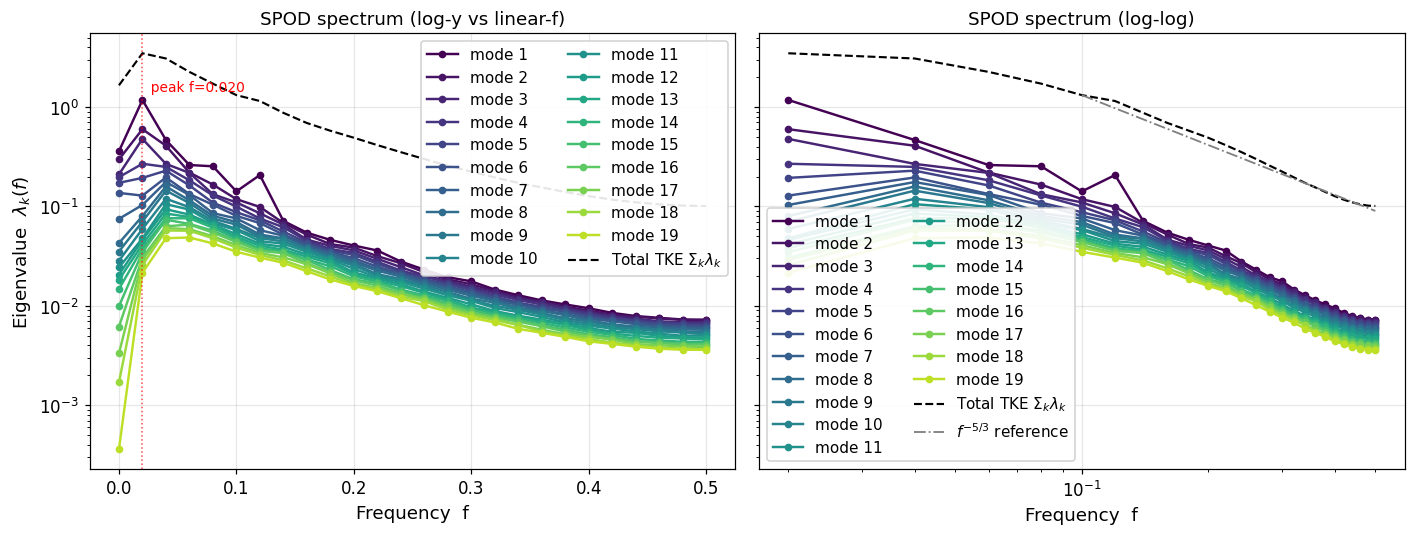

Figure saved: spod_spectrum.png
Peak mode-1 energy at f = 0.0200  (f_idx = 1)
Mode-1 / mode-2 ratio at peak: 1.97
Mode-1 share of total at peak: 33.9%


In [32]:
# =========================================================
# Analysis Step 3: SPOD eigenvalue spectrum
# =========================================================

# --- Set up colours: mode 1 bold, remaining modes in a gradient ---
cmap = plt.cm.viridis
mode_colors = [cmap(x) for x in np.linspace(0.0, 0.9, nblk_loaded)]

# For log-f plot, we need to drop f=0 (log(0) undefined)
f_nonzero     = freq_axis[1:]
eig_nonzero   = all_eigvals[1:, :]
tot_nonzero   = total_energy_per_f[1:]

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

# ---- Left panel: log-y vs linear-f ----
ax = axes[0]
for k in range(nblk_loaded):
    ax.semilogy(freq_axis, all_eigvals[:, k],
                marker='o', markersize=4,
                color=mode_colors[k],
                label=f"mode {k+1}")
# Total energy per frequency
ax.semilogy(freq_axis, total_energy_per_f,
            color='black', linestyle='--', linewidth=1.4,
            label=r"Total TKE $\Sigma_k \lambda_k$")
ax.set_xlabel("Frequency  f")
ax.set_ylabel(r"Eigenvalue  $\lambda_k(f)$")
ax.set_title("SPOD spectrum (log-y vs linear-f)")
ax.legend(ncol=2, loc="upper right", framealpha=0.9)

# Mark the peak frequency
ax.axvline(freq_axis[f_peak_idx], color='red', linestyle=':', linewidth=1, alpha=0.7)
ax.text(freq_axis[f_peak_idx], all_eigvals.max() * 1.15,
        f"  peak f={freq_axis[f_peak_idx]:.3f}",
        color='red', fontsize=9, va='bottom')

# ---- Right panel: log-y vs log-f ----
ax = axes[1]
for k in range(nblk_loaded):
    ax.loglog(f_nonzero, eig_nonzero[:, k],
              marker='o', markersize=4,
              color=mode_colors[k],
              label=f"mode {k+1}")
ax.loglog(f_nonzero, tot_nonzero,
          color='black', linestyle='--', linewidth=1.4,
          label=r"Total TKE $\Sigma_k \lambda_k$")

# Reference slope: f^(-5/3) anchored at (f=0.1, tot[f=0.1])
# This is the Kolmogorov inertial-range slope — useful visual reference
anchor_idx = np.argmin(np.abs(f_nonzero - 0.1))
anchor_f   = f_nonzero[anchor_idx]
anchor_y   = tot_nonzero[anchor_idx]
f_ref      = f_nonzero[anchor_idx:]
y_ref      = anchor_y * (f_ref / anchor_f) ** (-5.0/3.0)
ax.loglog(f_ref, y_ref, color='gray', linestyle='-.', linewidth=1.2,
          label=r"$f^{-5/3}$ reference")

ax.set_xlabel("Frequency  f")
ax.set_title("SPOD spectrum (log-log)")
ax.legend(ncol=2, loc="lower left", framealpha=0.9)

plt.tight_layout()
plt.savefig("spod_spectrum.png", bbox_inches="tight")
plt.show()

print("Figure saved: spod_spectrum.png")
print(f"Peak mode-1 energy at f = {freq_axis[f_peak_idx]:.4f}  (f_idx = {f_peak_idx})")
print(f"Mode-1 / mode-2 ratio at peak: {rank_sep[f_peak_idx]:.2f}")
print(f"Mode-1 share of total at peak: {coh_ratio[f_peak_idx]*100:.1f}%")

# Analysis Step 4 — Mode-1 dominance ratio vs frequency

Step 3 showed the raw energy distribution. Step 4 answers a sharper question:

> **At which frequencies does a single coherent structure dominate?**

We plot two ratios on the same axes:

1. **Coherence ratio** `λ₁(f) / Σₖ λₖ(f)` — fraction of that frequency's energy captured by mode 1 alone.  
   - Range: `[1/nblk, 1]` = `[0.143, 1]` for nblk=7.  
   - `1/nblk` = baseline for "energy spread evenly across all modes" (incoherent turbulence).  
   - Close to 1 = one structure dominates (rank-1 coherent).

2. **Rank separation** `λ₁(f) / λ₂(f)` — gap between the top two modes.  
   - `≥ 2`: conventional threshold (Schmidt & Colonius 2020) for calling a frequency "rank-1 dominant."  
   - `≈ 1`: modes 1 and 2 are competing (degenerate pair — could indicate a traveling-wave structure where mode 1 and 2 are a quadrature pair).

Overlaying them in one figure shows where **both** metrics are high — those are the strongest candidates for coherent structure extraction.

Reference lines drawn:
- Horizontal `1/nblk = 0.143` (incoherent baseline, for coherence ratio)
- Horizontal `λ₁/λ₂ = 2` (rank-1 threshold, for rank separation)

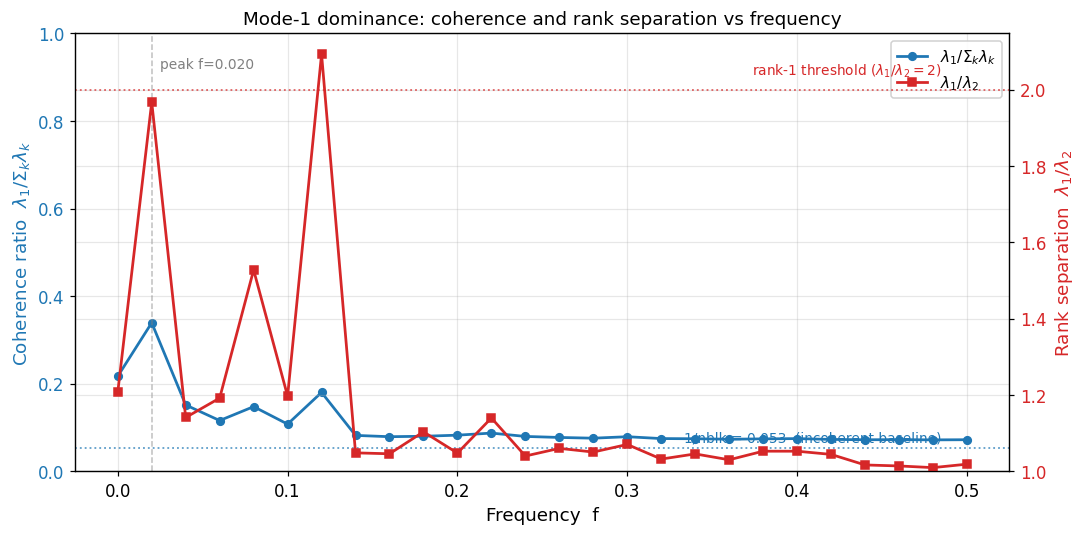

Figure saved: spod_dominance.png

Frequencies with coherence ratio >= 2/nblk = 0.105:
  f_idx= 0  f=0.0000  λ1/Σλ=0.217  λ1/λ2=1.21
  f_idx= 1  f=0.0200  λ1/Σλ=0.339  λ1/λ2=1.97
  f_idx= 2  f=0.0400  λ1/Σλ=0.151  λ1/λ2=1.14
  f_idx= 3  f=0.0600  λ1/Σλ=0.116  λ1/λ2=1.19
  f_idx= 4  f=0.0800  λ1/Σλ=0.148  λ1/λ2=1.53
  f_idx= 5  f=0.1000  λ1/Σλ=0.108  λ1/λ2=1.20
  f_idx= 6  f=0.1200  λ1/Σλ=0.180  λ1/λ2=2.09

Frequencies meeting rank-1 threshold (λ1/λ2 >= 2):
  f_idx= 6  f=0.1200  λ1/Σλ=0.180  λ1/λ2=2.09

Frequencies near rank-1 (1.5 <= λ1/λ2 < 2.0):
  f_idx= 1  f=0.0200  λ1/Σλ=0.339  λ1/λ2=1.97
  f_idx= 4  f=0.0800  λ1/Σλ=0.148  λ1/λ2=1.53


In [33]:
# =========================================================
# Analysis Step 4: Coherence ratio and rank separation vs f
# =========================================================

fig, ax1 = plt.subplots(1, 1, figsize=(10, 5))

# --- Left axis: coherence ratio λ1 / Σλ ---
color1 = "#1f77b4"
ax1.plot(freq_axis, coh_ratio,
         marker='o', markersize=5, linewidth=1.8,
         color=color1, label=r"$\lambda_1 / \Sigma_k \lambda_k$")
ax1.set_xlabel("Frequency  f")
ax1.set_ylabel(r"Coherence ratio  $\lambda_1 / \Sigma_k \lambda_k$",
               color=color1)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_ylim(0, 1)

# Baseline: 1/nblk (perfectly incoherent — energy evenly spread)
incoh_baseline = 1.0 / nblk_loaded
ax1.axhline(incoh_baseline, color=color1, linestyle=':', linewidth=1.2, alpha=0.7)
ax1.text(freq_axis[-1] * 0.97, incoh_baseline + 0.015,
         f"1/nblk = {incoh_baseline:.3f}  (incoherent baseline)",
         color=color1, fontsize=9, ha='right')

# --- Right axis: rank separation λ1/λ2 ---
ax2 = ax1.twinx()
color2 = "#d62728"
# Guard inf values (mode 2 = 0) for display; replace with a large placeholder
rank_sep_plot = np.where(np.isfinite(rank_sep), rank_sep,
                         np.nanmax(rank_sep[np.isfinite(rank_sep)]) * 1.2)
ax2.plot(freq_axis, rank_sep_plot,
         marker='s', markersize=5, linewidth=1.8,
         color=color2, label=r"$\lambda_1 / \lambda_2$")
ax2.set_ylabel(r"Rank separation  $\lambda_1 / \lambda_2$",
               color=color2)
ax2.tick_params(axis='y', labelcolor=color2)
ax2.set_ylim(bottom=1.0)

# Threshold: λ1/λ2 = 2 (rank-1 dominance)
ax2.axhline(2.0, color=color2, linestyle=':', linewidth=1.2, alpha=0.7)
ax2.text(freq_axis[-1] * 0.97, 2.0 + 0.04,
         r"rank-1 threshold ($\lambda_1/\lambda_2 = 2$)",
         color=color2, fontsize=9, ha='right')

# --- Shade the peak frequency for visual reference ---
ax1.axvline(freq_axis[f_peak_idx], color='gray',
            linestyle='--', linewidth=1, alpha=0.5)
ax1.text(freq_axis[f_peak_idx] + 0.005, 0.92,
         f"peak f={freq_axis[f_peak_idx]:.3f}",
         color='gray', fontsize=9)

# --- Title and legend ---
ax1.set_title("Mode-1 dominance: coherence and rank separation vs frequency")

# Combined legend (since we have two axes)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right", framealpha=0.9)
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("spod_dominance.png", bbox_inches="tight")
plt.show()

# --- Print the frequencies that pass each threshold ---
print("Figure saved: spod_dominance.png\n")

# High coherence: above incoherent baseline by a clear margin
# Use 2x the baseline = 0.286 as a practical "clearly above noise" threshold
coh_thresh = 2.0 * incoh_baseline
high_coh_idx = np.where(coh_ratio >= coh_thresh)[0]
print(f"Frequencies with coherence ratio >= 2/nblk = {coh_thresh:.3f}:")
for i in high_coh_idx:
    print(f"  f_idx={i:2d}  f={freq_axis[i]:.4f}  "
          f"λ1/Σλ={coh_ratio[i]:.3f}  λ1/λ2={rank_sep[i]:.2f}")

# Rank-1 threshold (λ1/λ2 >= 2)
rank1_idx = np.where(rank_sep >= 2.0)[0]
print(f"\nFrequencies meeting rank-1 threshold (λ1/λ2 >= 2):")
if rank1_idx.size == 0:
    print("  (none — no frequency is strictly rank-1 dominant)")
else:
    for i in rank1_idx:
        print(f"  f_idx={i:2d}  f={freq_axis[i]:.4f}  "
              f"λ1/Σλ={coh_ratio[i]:.3f}  λ1/λ2={rank_sep[i]:.2f}")

# Frequencies that are near rank-1 (>= 1.5)
near_rank1_idx = np.where((rank_sep >= 1.5) & (rank_sep < 2.0))[0]
print(f"\nFrequencies near rank-1 (1.5 <= λ1/λ2 < 2.0):")
if near_rank1_idx.size == 0:
    print("  (none)")
else:
    for i in near_rank1_idx:
        print(f"  f_idx={i:2d}  f={freq_axis[i]:.4f}  "
              f"λ1/Σλ={coh_ratio[i]:.3f}  λ1/λ2={rank_sep[i]:.2f}")

# Analysis Step 5 — Cumulative energy fraction

This step answers a practical question:

> **How many modes do I need to keep at each frequency to capture a given fraction of the energy?**

At each frequency, we sort modes by descending eigenvalue (already done) and build the cumulative energy fraction:

$$
F_K(f) \;=\; \frac{\sum_{k=1}^{K} \lambda_k(f)}{\sum_{k=1}^{N_{\text{blk}}} \lambda_k(f)}
$$

`F_K(f)` rises from `λ₁/Σλ` at K=1 to exactly 1.0 at K=nblk. The *shape* of that rise tells the story:

- **Low-rank, coherent frequencies** → `F_K` rises steeply (e.g., 80% captured with 2 modes).
- **Incoherent / turbulent frequencies** → `F_K` rises roughly linearly (every mode contributes ~1/nblk = 14%).

Two complementary views:
1. **Line plot `F_K(f)` for each K** — shows mode-by-mode saturation across the whole spectrum.
2. **Heatmap of `F_K(f)` with (frequency × K)** — easier to spot regime transitions at a glance.

A horizontal reference at `F = 0.9` marks the conventional 90%-energy threshold.

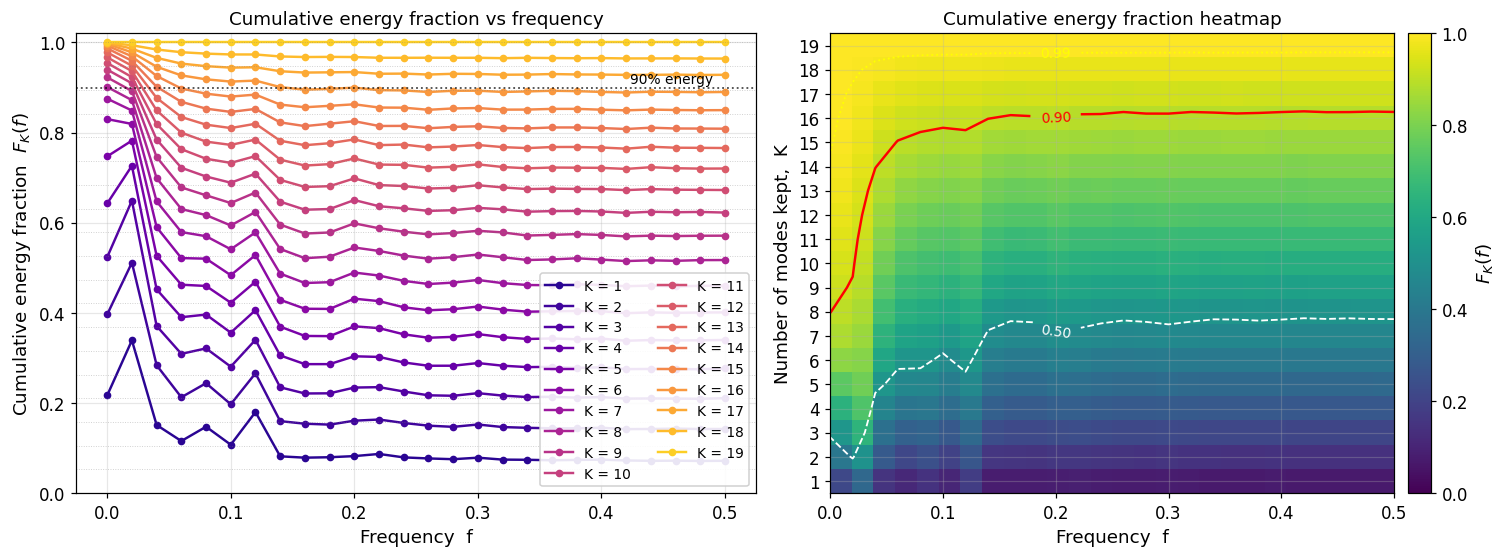

Figure saved: spod_cumulative_energy.png

Modes needed to reach X% of the energy (per frequency)
----------------------------------------------------------------
idx       f    50%    90%    99%
----------------------------------------------------------------
  0  0.0000      3      8     15
  1  0.0200      2     10     18
  2  0.0400      5     14     19
  3  0.0600      6     16     19
  4  0.0800      6     16     19
  5  0.1000      7     16     19
  6  0.1200      6     16     19
  7  0.1400      8     16     19
  8  0.1600      8     17     19
  9  0.1800      8     17     19
 10  0.2000      8     17     19
 11  0.2200      8     17     19
 12  0.2400      8     17     19
 13  0.2600      8     17     19
 14  0.2800      8     17     19
 15  0.3000      8     17     19
 16  0.3200      8     17     19
 17  0.3400      8     17     19
 18  0.3600      8     17     19
 19  0.3800      8     17     19
 20  0.4000      8     17     19
 21  0.4200      8     17     19
 22  0.4400   

In [34]:
# =========================================================
# Analysis Step 5: Cumulative energy fraction
# =========================================================

# cum_frac already computed in Step 2 — shape (nfreq, nblk)
# cum_frac[f, k-1] = F_k(f) = fraction of energy in top k modes at frequency f

# Also compute n_modes for 50%, 90%, 99% thresholds
def modes_needed(cumfrac, thresh):
    """Number of modes (1-indexed) needed to reach threshold at each freq."""
    under = (cumfrac < thresh).sum(axis=1) + 1
    return np.clip(under, 1, cumfrac.shape[1])

n_modes_50 = modes_needed(cum_frac, 0.50)
n_modes_90 = modes_needed(cum_frac, 0.90)
n_modes_99 = modes_needed(cum_frac, 0.99)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))

# -----------------------------------------------------------
# Left panel: line plot F_K(f) vs f, one line per K
# -----------------------------------------------------------
ax = axes[0]
cmap = plt.cm.plasma
k_colors = [cmap(x) for x in np.linspace(0.05, 0.9, nblk_loaded)]

for K in range(1, nblk_loaded + 1):
    ax.plot(freq_axis, cum_frac[:, K - 1],
            marker='o', markersize=4, linewidth=1.6,
            color=k_colors[K - 1],
            label=f"K = {K}")

# Reference: 90% energy line
ax.axhline(0.9, color='k', linestyle=':', linewidth=1.2, alpha=0.7)
ax.text(freq_axis[-1] * 0.98, 0.91, "90% energy", color='k',
        fontsize=9, ha='right')

# Reference: 1/nblk baseline (purely incoherent — every K gives K/nblk)
incoh_levels = np.arange(1, nblk_loaded + 1) / nblk_loaded
for K, lvl in enumerate(incoh_levels, start=1):
    ax.axhline(lvl, color='gray', linestyle=':', linewidth=0.6, alpha=0.4)

ax.set_xlabel("Frequency  f")
ax.set_ylabel(r"Cumulative energy fraction  $F_K(f)$")
ax.set_title("Cumulative energy fraction vs frequency")
ax.set_ylim(0, 1.02)
ax.legend(ncol=2, loc="lower right", fontsize=9, framealpha=0.9)

# -----------------------------------------------------------
# Right panel: heatmap of F_K(f)  (frequency on x, mode index on y)
# -----------------------------------------------------------
ax = axes[1]
# Transpose so K (mode count) is on y-axis, freq on x-axis
im = ax.imshow(
    cum_frac.T,
    aspect='auto',
    origin='lower',
    extent=[freq_axis[0], freq_axis[-1], 0.5, nblk_loaded + 0.5],
    cmap='viridis',
    vmin=0, vmax=1,
)
cbar = plt.colorbar(im, ax=ax, pad=0.02)
cbar.set_label(r"$F_K(f)$")

# Overlay contour at 90%
# contour expects 2D arrays with matching axes
K_grid, F_grid = np.meshgrid(np.arange(1, nblk_loaded + 1), freq_axis)
CS = ax.contour(F_grid, K_grid, cum_frac,
                levels=[0.5, 0.9, 0.99],
                colors=['white', 'red', 'yellow'],
                linewidths=[1.2, 1.6, 1.2],
                linestyles=['--', '-', ':'])
ax.clabel(CS, inline=True, fontsize=9, fmt='%.2f')

ax.set_xlabel("Frequency  f")
ax.set_ylabel("Number of modes kept,  K")
ax.set_title("Cumulative energy fraction heatmap")
ax.set_yticks(np.arange(1, nblk_loaded + 1))

plt.tight_layout()
plt.savefig("spod_cumulative_energy.png", bbox_inches="tight")
plt.show()

# -----------------------------------------------------------
# Textual summary: modes required to reach 50 / 90 / 99 %
# -----------------------------------------------------------
print("Figure saved: spod_cumulative_energy.png\n")
print("Modes needed to reach X% of the energy (per frequency)")
print("-" * 64)
print(f"{'idx':>3} {'f':>7}   {'50%':>4}   {'90%':>4}   {'99%':>4}")
print("-" * 64)
for i in range(nfreq_loaded):
    print(f"{i:3d} {freq_axis[i]:7.4f}   {n_modes_50[i]:4d}   "
          f"{n_modes_90[i]:4d}   {n_modes_99[i]:4d}")
print("-" * 64)

# Average effective rank
avg50 = n_modes_50.mean()
avg90 = n_modes_90.mean()
avg99 = n_modes_99.mean()
print(f"\nAverage modes needed across all frequencies:")
print(f"  50% energy : {avg50:.2f}")
print(f"  90% energy : {avg90:.2f}")
print(f"  99% energy : {avg99:.2f}  (max possible = {nblk_loaded})")

# Count frequencies where 2 modes capture >= 80%
n80_with_2 = ((cum_frac[:, 1] >= 0.80).sum())
print(f"\nFrequencies where the top 2 modes capture ≥ 80% of the energy: {n80_with_2}")
if n80_with_2 > 0:
    idx = np.where(cum_frac[:, 1] >= 0.80)[0]
    for i in idx:
        print(f"  f_idx={i}  f={freq_axis[i]:.4f}  F_2={cum_frac[i, 1]:.3f}")

# Analysis Step 6 — Select target frequencies for spatial inspection

Based on Steps 2–5 we now pick the frequency/mode combinations most worth visualizing.
The selection follows four criteria:

1. **Primary coherent peak** — the strongest mode-1 energy frequency.  
   From Step 2: `f_idx = 1  (f = 0.02)`.

2. **Harmonic / second peak** — frequencies that appear as integer multiples of the primary and have elevated coherence.  
   Candidates: f_idx = 3 (0.06 = 3·0.02), f_idx = 6 (0.12 = 6·0.02).

3. **High-f turbulent reference** — a frequency clearly in the incoherent plateau  
   (`λ₁/Σλ ≈ 0.19`, curves tightly bunched in the spectrum).  
   Chosen: f_idx = 20 (f = 0.40).

4. **Multi-rank structure at the peak** — Step 5 showed that at f=0.02, modes 1, 2, and 3 together  
   capture ~85% of the energy. We will inspect all three at the peak, and only mode 1 at the others.

The cell below builds a tidy list of `(f_idx, mode_idx, label)` tuples that later steps will consume,
and verifies the corresponding `Phi_freq_XXXX.dat` files are on disk.

In [35]:
# =========================================================
# Analysis Step 6: Select target (frequency, mode) pairs
# =========================================================

# Directory where the Phi_freq_XXXX.dat files live
# (they were written to the current working directory by the SPOD loop)
mode_file_dir = os.getcwd()

# --- Define target selections ---
# Each entry: (f_idx, mode_idx, role_label)
targets = [
    # Primary coherent peak — inspect first 3 modes (multi-rank per Step 5)
    ( 1, 0, "Primary peak f=0.02 — mode 1"),
    ( 1, 1, "Primary peak f=0.02 — mode 2"),
    ( 1, 2, "Primary peak f=0.02 — mode 3"),
    # Harmonic candidate (3x primary)
    ( 3, 0, "Harmonic f=0.06 — mode 1"),
    # Secondary coherent bump (6x primary, visible dip/peak pair in Step 4)
    ( 6, 0, "Secondary bump f=0.12 — mode 1"),
    # Turbulent reference in the incoherent plateau
    (20, 0, "Turbulent reference f=0.40 — mode 1"),
]

# Helper: build the mode filename for a given f_idx (matches the SPOD loop convention)
def mode_filename(f_idx):
    return os.path.join(mode_file_dir, f"Phi_freq_{f_idx:04d}.dat")

# --- Validate: files exist, sizes match the expected (ns_total, n_modes_keep) complex128 layout ---
expected_bytes = ns_total * n_modes_keep * np.dtype(complex_work_dtype).itemsize

print("Target (frequency, mode) selections")
print("-" * 90)
print(f"{'role':<42} {'f_idx':>6} {'f':>8} {'λk':>11} {'λk/Σλ':>9}  {'file ok?':>8}")
print("-" * 90)

all_files_ok = True
for (fi, mk, label) in targets:
    fname   = mode_filename(fi)
    exists  = os.path.exists(fname)
    size_ok = exists and (os.path.getsize(fname) == expected_bytes)
    status  = "OK" if size_ok else ("MISSING" if not exists else "BAD SIZE")
    if not size_ok:
        all_files_ok = False

    lam_k     = all_eigvals[fi, mk]
    lam_frac  = lam_k / total_energy_per_f[fi]
    print(f"{label:<42} {fi:>6d} {freq_axis[fi]:>8.4f} "
          f"{lam_k:>11.4e} {lam_frac:>8.3f}   {status:>8}")

print("-" * 90)
print(f"\nExpected file size per mode file: "
      f"{expected_bytes:,} bytes "
      f"(= {ns_total} spatial DOFs × {n_modes_keep} modes × 16 bytes/complex128)")

if all_files_ok:
    print("All selected mode files are present and correctly sized.")
else:
    print("!! Some mode files are missing or have wrong size. "
          "Re-run the Cell 54 loop before proceeding to Step 7.")

# Save the target list for use in later cells (so we can edit it once, not repeatedly)
analysis_targets = targets
print(f"\nStored {len(analysis_targets)} target selections in `analysis_targets`.")

Target (frequency, mode) selections
------------------------------------------------------------------------------------------
role                                        f_idx        f          λk     λk/Σλ  file ok?
------------------------------------------------------------------------------------------
Primary peak f=0.02 — mode 1                    1   0.0200  1.1780e+00    0.339         OK
Primary peak f=0.02 — mode 2                    1   0.0200  5.9872e-01    0.172         OK
Primary peak f=0.02 — mode 3                    1   0.0200  4.7824e-01    0.138         OK
Harmonic f=0.06 — mode 1                        3   0.0600  2.6110e-01    0.116         OK
Secondary bump f=0.12 — mode 1                  6   0.1200  2.0701e-01    0.180         OK
Turbulent reference f=0.40 — mode 1            20   0.4000  9.4636e-03    0.074         OK
------------------------------------------------------------------------------------------

Expected file size per mode file: 345,047,040 bytes (

# Analysis Step 7 — Load and reshape a spatial mode

This step writes a helper function that converts a flat SPOD mode column into a physically
interpretable 4D array.

Recall the index packing used throughout the pipeline:

1. Q's rows were stacked `[U_all; V_all; W_all]` (`dof = 3`), so the length-`ns_total` column
   splits as three length-`ns_one = Nx·Ny·Nz` blocks.
2. Each component block was stored in **C-order** with `(Nz, Ny, Nx)` shape, matching the
   original Fortran stream write order `(((·, I), J), K)` — i.e., `x` fastest, then `y`, then `z`.

The reverse operation is therefore:

flat (ns_total,)
→ split into 3 blocks of length ns_one                          # undo [U;V;W] stacking
→ reshape each block to (Nz, Ny, Nx) with C-order               # undo the flatten
→ stack to (3, Nz, Ny, Nx)                                      # final physical layout

Axis 0 of the returned array is: `0 = U` (streamwise), `1 = V` (spanwise), `2 = W` (wall-normal).

The helper opens each mode file as a `numpy.memmap` in read-only mode — no 345 MB copy into RAM
is made until we explicitly index one mode column. We then use `.copy()` on just that one column
so the returned array is a clean, independent NumPy array (not a memmap view), which matters
for later plotting and arithmetic.

After defining the helper, we run a sanity check on f=0.02 mode 1:
- shape, dtype
- component-wise magnitude statistics
- verify no NaN/Inf
- verify the three components are not identical (a failure mode of a wrong reshape)

In [36]:
# =========================================================
# Analysis Step 7: Helper to load and reshape a SPOD mode
# =========================================================

def load_spod_mode(f_idx, mode_idx,
                   nx=nx, ny=ny, nz=nz,
                   n_modes_keep=n_modes_keep,
                   complex_dtype=complex_work_dtype,
                   mode_file_dir=mode_file_dir):
    """
    Load one SPOD mode column and reshape it to (3, Nz, Ny, Nx).

    Parameters
    ----------
    f_idx : int
        Frequency index in [0, nfreq-1].
    mode_idx : int
        Mode index in [0, n_modes_keep-1] — 0 = mode 1.

    Returns
    -------
    phi4d : ndarray, shape (3, Nz, Ny, Nx), dtype complex128
        Axis 0:  0 = U (streamwise), 1 = V (spanwise), 2 = W (wall-normal)
        Axis 1:  z index (slowest)
        Axis 2:  y index (middle)
        Axis 3:  x index (fastest, matches Fortran I loop)
    """
    if not (0 <= mode_idx < n_modes_keep):
        raise IndexError(
            f"mode_idx={mode_idx} out of range [0, {n_modes_keep-1}]")

    ns_one   = nx * ny * nz
    ns_total = 3 * ns_one

    fname = os.path.join(mode_file_dir, f"Phi_freq_{f_idx:04d}.dat")
    if not os.path.exists(fname):
        raise FileNotFoundError(f"Mode file not found: {fname}")

    # Open as memmap (no large copy)
    Phi_mm = np.memmap(fname, dtype=complex_dtype, mode="r",
                       shape=(ns_total, n_modes_keep))

    # Pull out the one column we want, fully materialized into RAM
    col = np.asarray(Phi_mm[:, mode_idx]).copy()
    del Phi_mm  # release the memmap handle

    # Undo [U; V; W] stacking
    U_flat = col[0 * ns_one : 1 * ns_one]
    V_flat = col[1 * ns_one : 2 * ns_one]
    W_flat = col[2 * ns_one : 3 * ns_one]

    # Undo Fortran stream → C-order (Nz, Ny, Nx) reshape
    U3d = U_flat.reshape(nz, ny, nx, order='C')
    V3d = V_flat.reshape(nz, ny, nx, order='C')
    W3d = W_flat.reshape(nz, ny, nx, order='C')

    phi4d = np.stack([U3d, V3d, W3d], axis=0)
    return phi4d


# =========================================================
# Sanity check the helper on f_idx=1 (f=0.02), mode 1
# =========================================================
phi_test = load_spod_mode(f_idx=1, mode_idx=0)

print("Helper test: f_idx=1 (f=0.02), mode 1")
print("-" * 62)
print(f"phi_test.shape = {phi_test.shape}   "
      f"(expected (3, {nz}, {ny}, {nx}))")
print(f"phi_test.dtype = {phi_test.dtype}")
print(f"N elements      = {phi_test.size:,}  "
      f"(expected {3*nx*ny*nz:,})")

# Finiteness
n_nan = np.isnan(phi_test).sum()
n_inf = np.isinf(phi_test).sum()
print(f"NaN count       = {n_nan}")
print(f"Inf count       = {n_inf}")

# Magnitude stats per component
comp_names = ["U (streamwise)", "V (spanwise)", "W (wall-normal)"]
print("\nPer-component |Φ| statistics:")
print(f"{'component':<20} {'min':>11} {'max':>11} "
      f"{'mean':>11} {'std':>11}")
print("-" * 62)
for c in range(3):
    mag = np.abs(phi_test[c])
    print(f"{comp_names[c]:<20} "
          f"{mag.min():>11.4e} {mag.max():>11.4e} "
          f"{mag.mean():>11.4e} {mag.std():>11.4e}")

# Verify the three components are NOT bit-identical (catches a reshape bug)
u_eq_v = np.array_equal(phi_test[0], phi_test[1])
u_eq_w = np.array_equal(phi_test[0], phi_test[2])
v_eq_w = np.array_equal(phi_test[1], phi_test[2])
print(f"\nAre components identical?  "
      f"U==V: {u_eq_v}    U==W: {u_eq_w}    V==W: {v_eq_w}")
print("(All three must be False — otherwise the [U;V;W] un-stacking failed.)")

# Cross-check with the stored eigenvalue:
# The W-weighted norm of this mode should equal 1
# (Φ^H W Φ = I  →  diag(Φ^H W Φ) = 1 for each mode)
# We computed this chunked in the pipeline; here we do it directly since a single mode fits in RAM.
phi_flat = np.concatenate([phi_test[c].ravel(order='C') for c in range(3)])
w_norm_sq = float(np.real(np.sum(W_1D * np.abs(phi_flat)**2)))
print(f"\nW-weighted norm squared of this mode: {w_norm_sq:.6f}  "
      f"(expected 1.0)")

# Per-component energy share (fraction of mode's total energy in each velocity component)
energies = np.array([
    float(np.sum(W_1D[c*ns_one:(c+1)*ns_one] * np.abs(phi_test[c].ravel(order='C'))**2))
    for c in range(3)
])
print("\nPer-component W-weighted energy share:")
for c in range(3):
    print(f"  {comp_names[c]:<20}  {energies[c]:.4f}  "
          f"({100*energies[c]/energies.sum():.1f}%)")

Helper test: f_idx=1 (f=0.02), mode 1
--------------------------------------------------------------
phi_test.shape = (3, 65, 192, 192)   (expected (3, 65, 192, 192))
phi_test.dtype = complex128
N elements      = 7,188,480  (expected 7,188,480)
NaN count       = 0
Inf count       = 0

Per-component |Φ| statistics:
component                    min         max        mean         std
--------------------------------------------------------------
U (streamwise)        2.7878e-06  2.1386e-01  6.8821e-02  4.1151e-02
V (spanwise)          0.0000e+00  1.3328e-01  3.5403e-02  2.4305e-02
W (wall-normal)       0.0000e+00  1.0423e-01  2.0874e-02  1.8878e-02

Are components identical?  U==V: False    U==W: False    V==W: False
(All three must be False — otherwise the [U;V;W] un-stacking failed.)

W-weighted norm squared of this mode: 1.000000  (expected 1.0)

Per-component W-weighted energy share:
  U (streamwise)        0.6802  (68.0%)
  V (spanwise)          0.2160  (21.6%)
  W (wall-normal)    

# Analysis Step 8 — Phase-Aligned Vertical (x–z) Slices of the Primary Coherent Mode

## The phase-alignment problem

SPOD modes are complex-valued: each grid point carries both a magnitude and a phase.
A mode $\Phi$ is defined only up to an arbitrary global phase — the replacement
$\Phi \rightarrow e^{i\varphi}\Phi$ satisfies the same eigenvalue equation and
W-orthonormality condition for any $\varphi$. Different choices of $\varphi$ correspond
to different instants in the oscillation cycle of the underlying propagating structure.

To obtain a canonical, reproducible snapshot of the mode, we select the phase $\varphi^*$
that maximises the W-weighted squared real part:

$$
\varphi^{\star} = \arg\max_{\varphi} \left\|\,\operatorname{Re}(e^{-i\varphi}\,\Phi)\,\right\|^2_W
$$

This has the closed-form solution:

$$
\varphi^{\star} = \tfrac{1}{2}\,\arg\!\left(\sum_n w_n\,\Phi_n^2\right)
$$

where $w_n$ are the diagonal weights of $W$ accounting for non-uniform wall-normal
grid spacing. After rotating by $e^{-i\varphi^*}$, we display the real part
$\operatorname{Re}(e^{-i\varphi^*}\Phi)$ — the peak-energy snapshot of the mode.

The real-part energy fraction after alignment is a direct physical diagnostic:
a value near $100\%$ indicates a standing wave, while a value near $50\%$ confirms
a purely propagating (traveling) wave, since the energy of a traveling wave is
partitioned equally between its real and imaginary quadrature components.

## What this step produces

Turbulence in wall-bounded and wind-wave flows is fundamentally three-dimensional.
Vertical ($x$–$z$) slices at mid-span ($y = L_y/2$) reveal the wall-normal organisation
of coherent structures, their degree of surface-attachment, and the forward-leaning
inclination caused by mean-shear deformation — information that horizontal slices
cannot provide.

We render **mode 1** at four target frequencies ($f = 0.02,\ 0.06,\ 0.12,\ 0.40$)
in a single compact figure:

- **3 rows**: velocity components $U$, $V$, $W$
- **4 columns**: increasing frequency left to right
- Each panel uses its own symmetric colour scale so that structure is visible
  at every frequency, even as overall amplitude decreases with $f$

The four frequencies were chosen to sample the three spectral regimes identified
in Step 2: the primary coherent peak ($f=0.02$), intermediate coherent range
($f=0.06$, $f=0.12$), and the incoherent turbulent reference ($f=0.40$).
Plotting them side-by-side allows direct visual confirmation of the frequency–scale
separation inherent to the turbulent energy cascade.

The following step (Step 9.1) repeats this procedure for modes 2 and 3 at the
same four frequencies, enabling a direct comparison of the multi-rank coherent
structure family at $f=0.02$.

y-slice index: 96,  y = 4.7369

f = 0.0200  done  (phi* = -18.0°)
f = 0.0600  done  (phi* = +34.0°)
f = 0.1200  done  (phi* = +29.4°)
f = 0.4000  done  (phi* = +84.5°)


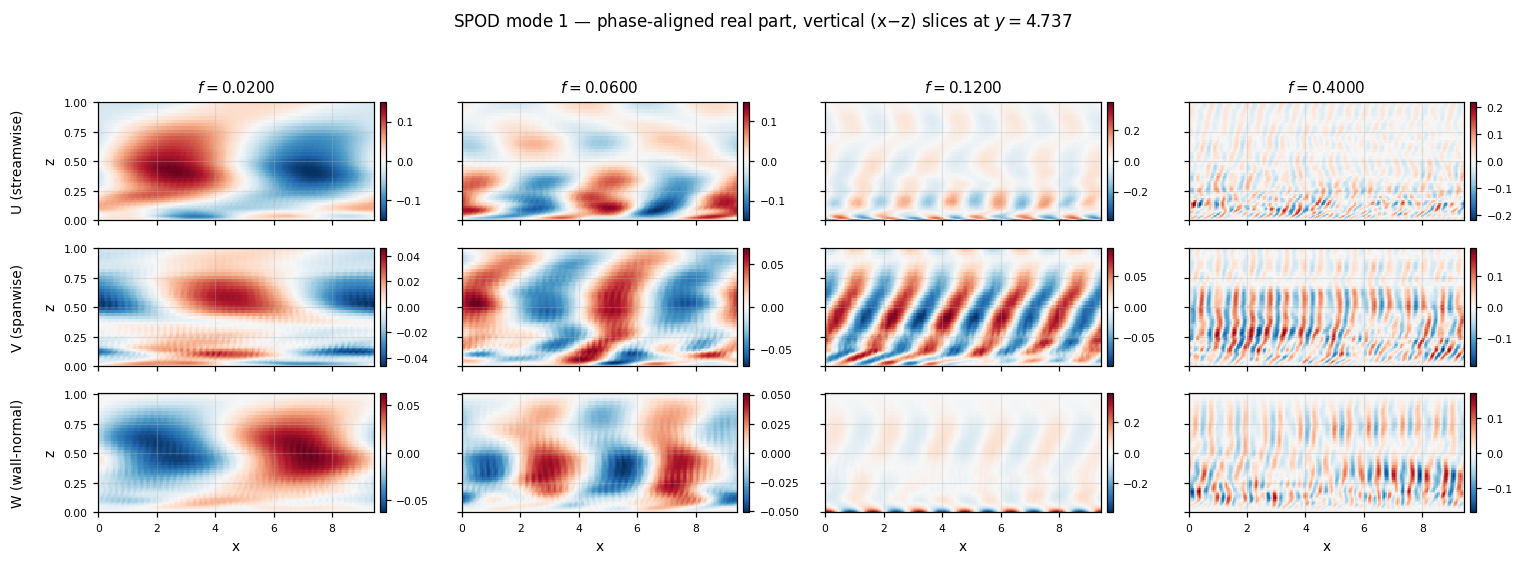


Figure saved: spod_mode1_multifreq_xzslices.png


In [56]:
# =========================================================
# Analysis Step 9: 4-frequency vertical (x-z) slice figure
# Layout: 3 rows (U, V, W) x 4 columns (frequencies)
# =========================================================

# ---------------------------------------------------------
# 1. THE TOOLS (Must be defined before plotting!)
# ---------------------------------------------------------

# --- Build physical coordinate axes ---
# x, y are uniform: Lx = Ly = 3*pi, cell centers
x = (np.arange(nx) + 0.5) * (Lx / nx)
y = (np.arange(ny) + 0.5) * (Ly / ny)

# z coordinates come from the same file used to build W_1D
z = np.loadtxt(z_file).astype(np.float64)
assert z.size == nz, "z_coordinates.txt size mismatch"

# --- The Phase-Alignment Math Function ---
def phase_align(phi4d, W_1D=W_1D, ns_one=ns_one):
    """
    Rotate a complex mode by e^(-i phi*) so that the W-weighted squared real part
    is maximized. Returns (phi_aligned_complex, phi_star_radians).
    """
    # Flatten back to a single (ns_total,) vector matching W_1D's ordering
    phi_flat = np.concatenate([phi4d[c].ravel(order='C') for c in range(3)])
    # Closed-form optimum:  phi* = 0.5 * arg( sum_n w_n * Phi_n^2 )
    s = np.sum(W_1D * (phi_flat ** 2))            # complex scalar
    phi_star = 0.5 * np.angle(s)
    rot = np.exp(-1j * phi_star)
    return rot * phi4d, phi_star

# ---------------------------------------------------------
# 2. THE PLOT (Multi-frequency x-z slices)
# ---------------------------------------------------------

# --- Target frequencies ---
target_fidx  = [1,      3,      6,      20    ]
target_freqs = [0.0200, 0.0600, 0.1200, 0.4000]

# --- Choose a single y-plane (mid-span) ---
j_mid = ny // 2
print(f"y-slice index: {j_mid},  y = {y[j_mid]:.4f}\n")

# --- Component names ---
comp_names  = ["U (streamwise)", "V (spanwise)", "W (wall-normal)"]
comp_labels = ["U", "V", "W"]

# --- Figure: 3 rows x 4 columns ---
fig, axes = plt.subplots(3, 4, figsize=(14, 5), sharex=True, sharey=True)

for col, (fi, freq) in enumerate(zip(target_fidx, target_freqs)):

    # Load and phase-align
    phi_raw      = load_spod_mode(f_idx=fi, mode_idx=0)
    phi_aln, phi_star = phase_align(phi_raw)
    phi_re       = phi_aln.real          # shape (3, nz, ny, nx)

    for row, c in enumerate(range(3)):
        ax    = axes[row, col]
        field = phi_re[c, :, j_mid, :]   # shape (nz, nx)
        
        # Find local max for this specific slice for optimal contrast
        v     = np.max(np.abs(field))
        if v == 0:
            v = 1e-16

        # Paint the 2D data onto the grid
        im = ax.pcolormesh(x, z, field,
                           cmap="RdBu_r",
                           vmin=-v, vmax=+v,
                           shading='auto')

        # Add a colorbar to every subplot
        cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
        cbar.ax.tick_params(labelsize=7)

        # --- Clean Publication-Ready Labeling ---
        
        # 1. Top row ONLY gets the frequency title
        if row == 0:
            ax.set_title(f"$f = {freq:.4f}$", fontsize=10)
            
        # 2. Left column ONLY gets the component name and z-axis label
        if col == 0:
            ax.set_ylabel(f"{comp_names[c]}\n\nz", fontsize=9)

        # 3. Bottom row ONLY gets the x-axis label
        if row == 2:
            ax.set_xlabel("x", fontsize=9)

        ax.tick_params(labelsize=7)
        ax.set_aspect('auto')

    print(f"f = {freq:.4f}  done  (phi* = {np.degrees(phi_star):+.1f}°)")

# Global Title
fig.suptitle(
    rf"SPOD mode 1 — phase-aligned real part, "
    rf"vertical (x$-$z) slices at $y = {y[j_mid]:.3f}$",
    fontsize=11, y=1.02
)

plt.tight_layout()
plt.savefig("spod_mode1_multifreq_xzslices.png", bbox_inches="tight", dpi=150)
plt.show()
print("\nFigure saved: spod_mode1_multifreq_xzslices.png")

# Analysis Step 9— Multi-Frequency Vertical (x–z) Slices for Modes 2 and 3

## Context

Step 8 established that mode 1 at $f = 0.02$ is a downstream-propagating,
streamwise-dominated coherent structure with component partition
$U:V:W = 68.0\%:21.6\%:10.4\%$. However, modes 1, 2, and 3 together
capture approximately $85\%$ of the total energy at this frequency
($33.9\% + 27.2\% + 11.4\%$), meaning the flow at $f = 0.02$ is
fundamentally multi-rank. This step examines whether modes 2 and 3
represent physically independent coherent structures or are simply
variants of mode 1.

Three interpretations are possible, each with a distinct visual signature:

| Interpretation | Expected signature in modes 2 and 3 |
|---|---|
| **Harmonics** | Same spatial footprint as mode 1 but with higher streamwise/spanwise wavenumber |
| **Shifted copies** | Same wavelengths as mode 1 but at different spatial phase positions |
| **Independent structures** | Different wall-normal localisation, different spatial scales, different $U:V:W$ partition |

## What this step produces

Applying the same canonical phase-alignment procedure and mid-span vertical
($x$–$z$) slice approach as Step 8, we render modes 2 and 3 each across the
same four target frequencies ($f = 0.02,\ 0.06,\ 0.12,\ 0.40$):

- **Two figures** — one per mode (mode 2, mode 3)
- Each figure: **3 rows** ($U$, $V$, $W$) × **4 columns** (frequencies)
- Layout and colour scaling identical to Step 8 for direct visual comparison

The phase angle $\varphi^\star$ is computed independently for each
mode at each frequency, since different modes at the same frequency
carry different phase information.

A summary table is printed at the end comparing the $\lambda_k / \sum\lambda_k$
energy share, Re-dominance, and $U:V:W$ partition across all three modes at
$f = 0.02$. The Re-dominance diagnostic is again the decisive test: a value
near $50\%$ for modes 2 and 3 would confirm that each mode independently
represents a propagating structure rather than a residual or correction term
to mode 1.

y-slice index: 96,  y = 4.7369


Mode 2 — vertical (x-z) slices across frequencies

  f=0.0200, mode 2
  phi* = -0.4746 rad (-27.19 deg)
  Re-dominance:   50.1%   (Re=0.501, Im=0.499, sum=1.000)
  U : V : W    =  72.2% : 17.7% : 10.1%

  f=0.0600, mode 2
  phi* = +1.1714 rad (+67.11 deg)
  Re-dominance:   50.0%   (Re=0.500, Im=0.500, sum=1.000)
  U : V : W    =  52.1% : 32.3% : 15.6%

  f=0.1200, mode 2
  phi* = +1.4585 rad (+83.57 deg)
  Re-dominance:   50.0%   (Re=0.500, Im=0.500, sum=1.000)
  U : V : W    =  37.5% : 39.7% : 22.9%

  f=0.4000, mode 2
  phi* = -0.1987 rad (-11.38 deg)
  Re-dominance:   50.0%   (Re=0.500, Im=0.500, sum=1.000)
  U : V : W    =  26.3% : 40.7% : 32.9%


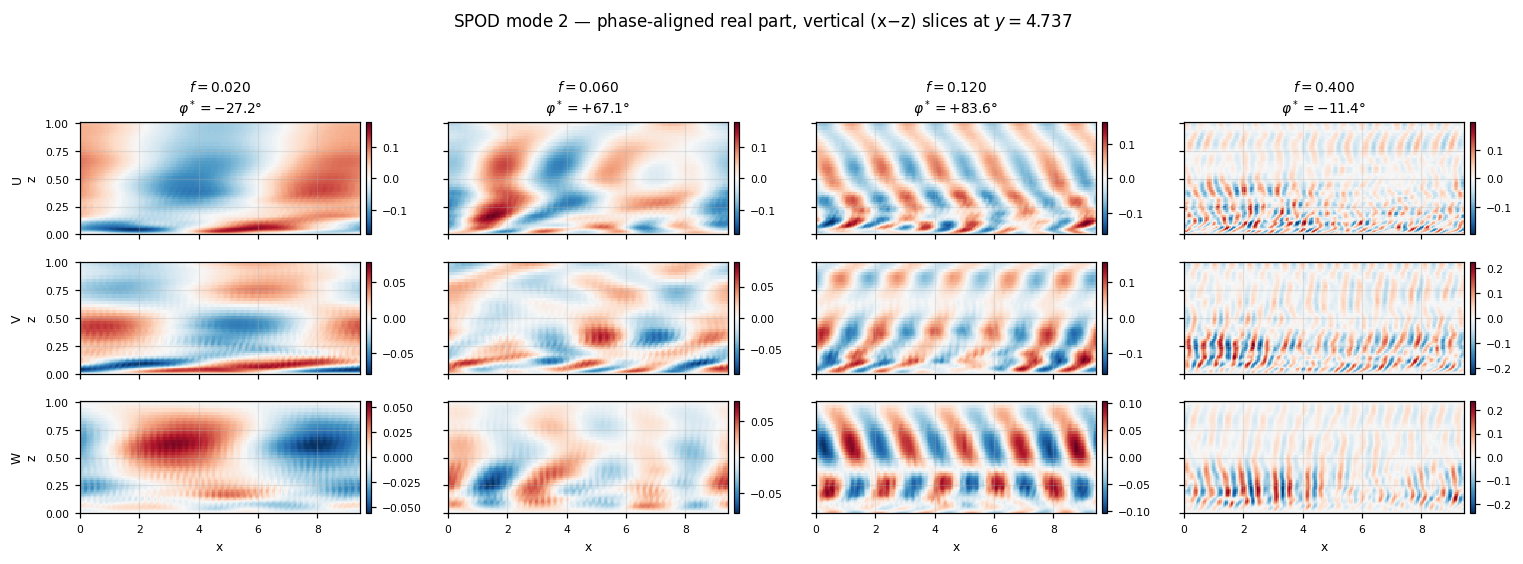


Figure saved: spod_mode2_multifreq_xzslices.png

Mode 3 — vertical (x-z) slices across frequencies

  f=0.0200, mode 3
  phi* = +0.5319 rad (+30.48 deg)
  Re-dominance:   50.3%   (Re=0.503, Im=0.497, sum=1.000)
  U : V : W    =  76.0% : 14.6% : 9.5%

  f=0.0600, mode 3
  phi* = +1.3832 rad (+79.25 deg)
  Re-dominance:   50.0%   (Re=0.500, Im=0.500, sum=1.000)
  U : V : W    =  49.4% : 34.4% : 16.2%

  f=0.1200, mode 3
  phi* = +0.0702 rad (+4.02 deg)
  Re-dominance:   50.0%   (Re=0.500, Im=0.500, sum=1.000)
  U : V : W    =  39.6% : 36.8% : 23.6%

  f=0.4000, mode 3
  phi* = +0.4700 rad (+26.93 deg)
  Re-dominance:   50.0%   (Re=0.500, Im=0.500, sum=1.000)
  U : V : W    =  27.1% : 40.0% : 32.8%


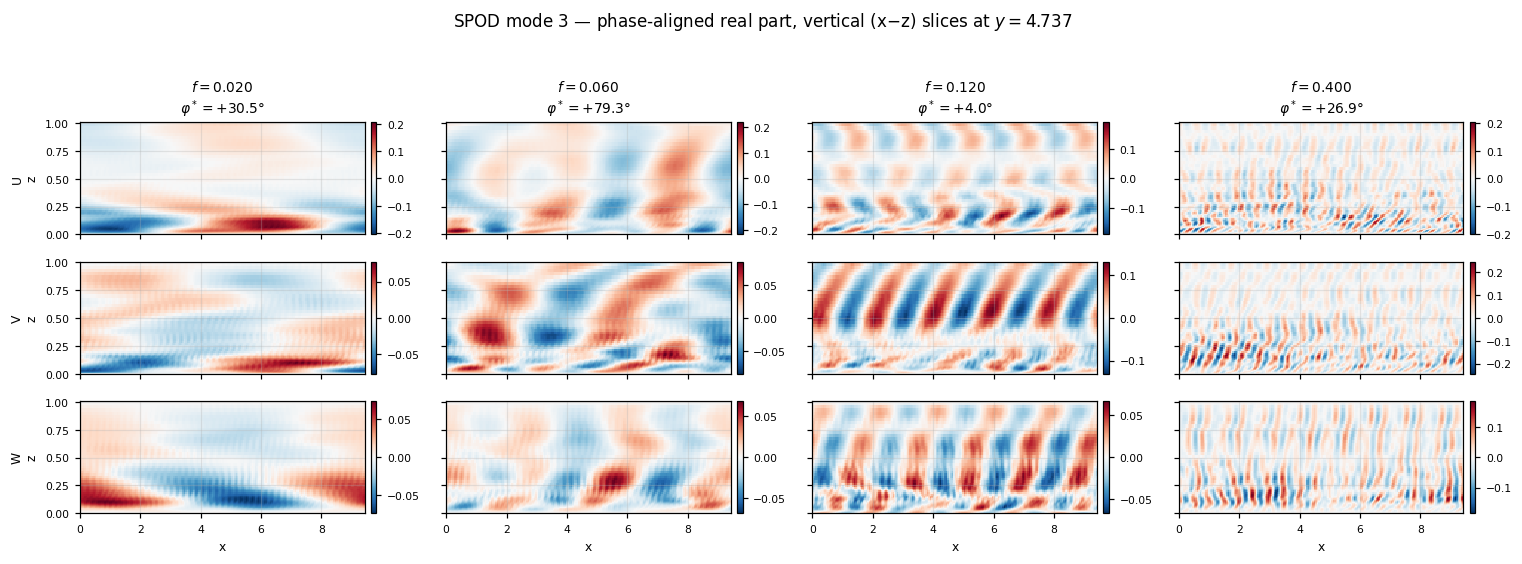


Figure saved: spod_mode3_multifreq_xzslices.png

Summary: modes 1, 2, 3 at f=0.02
mode      λk/Σλ   Re-dom     U %    V %    W %
------------------------------------------------------------------
1         0.339    50.3%   68.0%  21.6%  10.4%
2         0.172    50.1%   72.2%  17.7%  10.1%
3         0.138    50.3%   76.0%  14.6%   9.5%
------------------------------------------------------------------


In [58]:
# =========================================================
# Analysis Step 9.1 — Multi-frequency vertical (x-z) slices
# for modes 2 and 3 (mirrors Step 8.1 layout)
# =========================================================

# --- Target frequencies (same as Step 8.1) ---
target_fidx  = [1,      3,      6,      20    ]
target_freqs = [0.0200, 0.0600, 0.1200, 0.4000]

# --- Mid-span y-plane (same as Step 8.1) ---
j_mid = ny // 2
print(f"y-slice index: {j_mid},  y = {y[j_mid]:.4f}\n")

# --- Component names ---
comp_names  = ["U (streamwise)", "V (spanwise)", "W (wall-normal)"]
comp_labels = ["U", "V", "W"]

# --- Loop over modes 2 and 3 (mode_idx = 1 and 2) ---
for mode_idx in (1, 2):
    mode_label = mode_idx + 1    # human-readable: 2 or 3

    print(f"\n{'='*60}")
    print(f"Mode {mode_label} — vertical (x-z) slices across frequencies")
    print(f"{'='*60}")

    # --- Figure: 3 rows (U,V,W) x 4 columns (frequencies) ---
    fig, axes = plt.subplots(3, 4, figsize=(14, 5),
                             sharex=True, sharey=True)

    for col, (fi, freq) in enumerate(zip(target_fidx, target_freqs)):

        # Load and phase-align this mode at this frequency
        phi_raw      = load_spod_mode(f_idx=fi, mode_idx=mode_idx)
        phi_aln, phi_star = phase_align(phi_raw)
        phi_re       = phi_aln.real          # shape (3, nz, ny, nx)

        # Compute diagnostics
        re_e, im_e, splits = print_mode_summary(
            f"  f={freq:.4f}, mode {mode_label}", phi_aln, phi_star
        )

        for row, c in enumerate(range(3)):
            ax    = axes[row, col]
            field = phi_re[c, :, j_mid, :]   # shape (nz, nx)
            v     = np.max(np.abs(field))
            if v == 0:
                v = 1e-16

            im = ax.pcolormesh(x, z, field,
                               cmap="RdBu_r",
                               vmin=-v, vmax=+v,
                               shading='auto')

            cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
            cbar.ax.tick_params(labelsize=7)

            # Column title (frequency) on top row only
            if row == 0:
                ax.set_title(
                    f"$f = {freq:.3f}$\n"
                    f"$\\varphi^*={np.degrees(phi_star):+.1f}°$",
                    fontsize=9
                )

            # Component label on left column only
            if col == 0:
                ax.set_ylabel(f"{comp_labels[c]}\nz", fontsize=8)

            # x-label on bottom row only
            if row == 2:
                ax.set_xlabel("x", fontsize=8)

            ax.tick_params(labelsize=7)
            ax.set_aspect('auto')

    fig.suptitle(
        rf"SPOD mode {mode_label} — phase-aligned real part, "
        rf"vertical (x$-$z) slices at $y = {y[j_mid]:.3f}$",
        fontsize=11, y=1.02
    )

    plt.tight_layout()
    fname = f"spod_mode{mode_label}_multifreq_xzslices.png"
    plt.savefig(fname, bbox_inches="tight", dpi=150)
    plt.show()
    print(f"\nFigure saved: {fname}")

# --- Summary table: modes 1, 2, 3 at f=0.02 ---
print("\n" + "=" * 66)
print("Summary: modes 1, 2, 3 at f=0.02")
print("=" * 66)
print(f"{'mode':<6} {'λk/Σλ':>8} {'Re-dom':>8}  {'U %':>6} {'V %':>6} {'W %':>6}")
print("-" * 66)

# Mode 1 from Step 8 variables
phi1_flat  = np.concatenate([phi_prim[c].ravel(order='C') for c in range(3)])
mode1_re_e = float(np.sum(W_1D * phi1_flat.real**2))
mode1_splits = component_energy_split(phi_prim)
print(f"{'1':<6} {all_eigvals[1,0]/total_energy_per_f[1]:>8.3f} "
      f"{100*mode1_re_e:>7.1f}%  "
      f"{100*mode1_splits[0]:>5.1f}% "
      f"{100*mode1_splits[1]:>5.1f}% "
      f"{100*mode1_splits[2]:>5.1f}%")

# Modes 2 and 3 at f=0.02 only
for mode_idx in (1, 2):
    phi_raw      = load_spod_mode(f_idx=1, mode_idx=mode_idx)
    phi_aln, phi_star = phase_align(phi_raw)
    splits       = component_energy_split(phi_aln)
    phi_flat     = np.concatenate([phi_aln[c].ravel(order='C') for c in range(3)])
    re_e         = float(np.sum(W_1D * phi_flat.real**2))
    print(f"{mode_idx+1:<6} {all_eigvals[1,mode_idx]/total_energy_per_f[1]:>8.3f} "
          f"{100*re_e:>7.1f}%  "
          f"{100*splits[0]:>5.1f}% "
          f"{100*splits[1]:>5.1f}% "
          f"{100*splits[2]:>5.1f}%")

print("-" * 66)

# Analysis Step 10 — Wall-normal profiles and component shares vs frequency

This is the final analytical step before bookkeeping. It produces two clean, paper-ready plots
that consolidate everything we've learned into quantitative form.

### Panel A — Wall-normal energy profile E(z) for mode 1 at the four target frequencies

For each mode we integrate |Φ(x,y,z)|² over x and y and sum all three components:

$$
E_k(z; f) \;=\; \int\!\!\int \bigl(|U|^2 + |V|^2 + |W|^2\bigr) \, dx \, dy
$$

This shows **where in z** each coherent structure is concentrated. From Step 10 we already know
mode 1 at f=0.02 peaks at z=0.051 with centroid z̄=0.285. Here we compare that profile to the
ones at f=0.06, 0.12, and 0.40 — does the coherent structure migrate upward with frequency?
Does the turbulent reference (f=0.40) show a different vertical footprint?

All four profiles are normalized so they can be compared on the same axes (each peaks at 1.0).
Alongside the normalized profiles we also print the actual peak heights and centroids.

### Panel B — U:V:W energy share vs frequency, all 26 bins

Not just the four targets — we sweep mode 1 across **every** frequency and plot the three
component shares as stacked or line curves. This makes the anisotropy cascade we identified
qualitatively in Step 11 into a clean quantitative curve: how does U, V, W energy partition
with frequency across the entire spectrum?

This is a computation-heavy step — 26 mode files × 3 reshapes each = reading about 9 GB
of Phi data from disk. We only need the absolute magnitude squared, not the full complex
field, so we process one frequency at a time and never hold more than one mode in RAM.

The two panels together tell the full spatial-structural story for mode 1 across the spectrum.

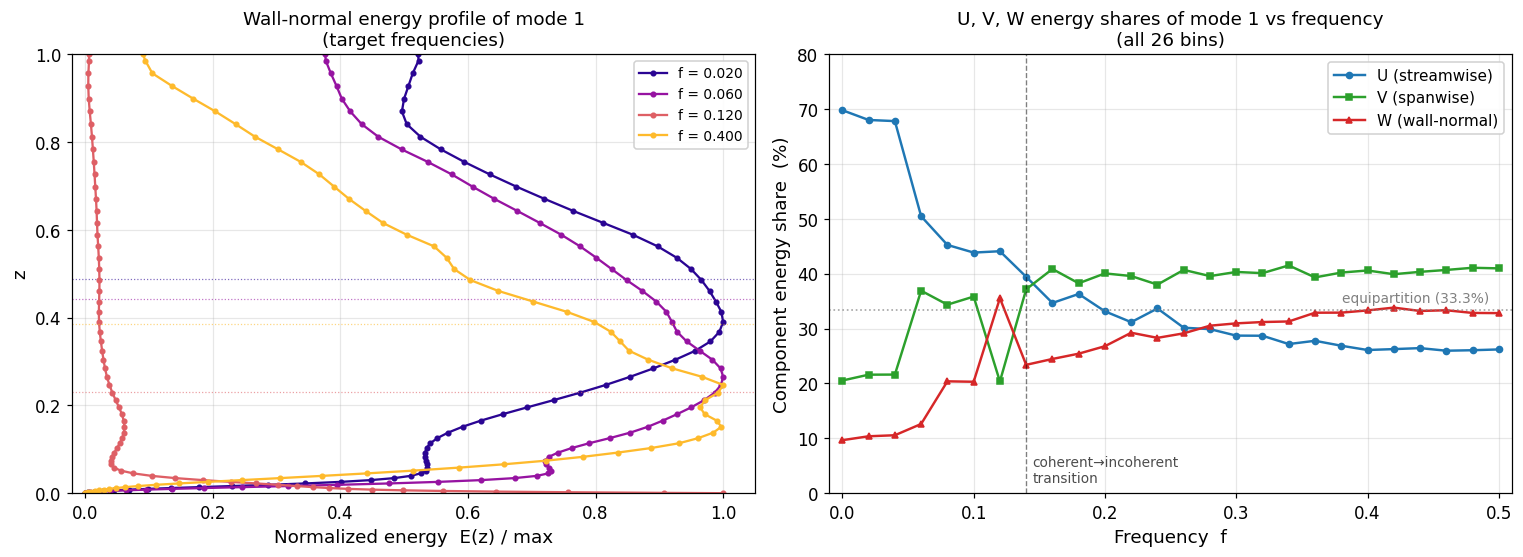

Figure saved: spod_zprofile_uvw.png

Panel A — wall-normal profile summary:
------------------------------------------------------------
f_idx       f   z_peak   z_centre     ∫E dz
------------------------------------------------------------
    1  0.0200   0.3901     0.4884  1.000000
    3  0.0600   0.2651     0.4434  1.000000
    6  0.1200   0.0000     0.2311  1.000000
   20  0.4000   0.2467     0.3862  1.000000
------------------------------------------------------------
(∫E dz should be ≈ 1.000 for all — mode orthonormality check.)

Panel B — U:V:W trend (first and last few bins):
----------------------------------------------------------------------
f_idx       f         U %    V %    W %   regime
----------------------------------------------------------------------
    0  0.0000       69.8%  20.5%   9.7%   primary coherent
    1  0.0200       68.0%  21.6%  10.4%   primary coherent
    2  0.0400       67.8%  21.6%  10.6%   primary coherent
    3  0.0600       50.5%  36.9%  12.6% 

In [41]:
# =========================================================
# Analysis Step 12+13: z-profiles (targets) and U:V:W (all f)
# =========================================================

# ---- dz weights (reuse from W_1D derivation for consistency) ----
dz = np.empty(nz)
dz[0]    = 0.5 * (z[1]  - z[0])
dz[-1]   = 0.5 * (z[-1] - z[-2])
dz[1:-1] = 0.5 * (z[2:] - z[:-2])

# ---- Helper: E(z) for a loaded mode ----
def wallnormal_profile(phi4d, dx=Lx/nx, dy=Ly/ny):
    """Return E(z) = integral of |phi|^2 over (x,y), summed over U,V,W."""
    E = np.zeros(nz)
    for c in range(3):
        E += (np.abs(phi4d[c])**2).sum(axis=(1, 2)) * dx * dy
    return E

# ---- Helper: per-component energy shares (already have from earlier) ----
# component_energy_split is defined from Step 9.

# =========================================================
# Panel A: z-profiles for the four target frequencies
# =========================================================
target_fidx_A = [1, 3, 6, 20]

z_profiles = {}
for fi in target_fidx_A:
    phi4d = load_spod_mode(f_idx=fi, mode_idx=0)
    E_z   = wallnormal_profile(phi4d)

    # Diagnostics
    k_peak   = int(np.argmax(E_z))
    z_peak_v = z[k_peak]
    z_centre = float(np.sum(z * E_z * dz) / np.sum(E_z * dz))
    total    = float(np.sum(E_z * dz))       # should be 1.0

    z_profiles[fi] = {
        "E_z":      E_z,
        "z_peak":   z_peak_v,
        "z_centre": z_centre,
        "total":    total,
    }

# =========================================================
# Panel B: U:V:W shares for ALL 26 frequencies, mode 1
# =========================================================
uvw_shares = np.zeros((nfreq_loaded, 3))
for fi in range(nfreq_loaded):
    phi4d = load_spod_mode(f_idx=fi, mode_idx=0)
    uvw_shares[fi, :] = component_energy_split(phi4d)

# Verify each row sums to ~1.0
row_sums = uvw_shares.sum(axis=1)
assert np.allclose(row_sums, 1.0, atol=1e-6), \
    f"Component shares don't sum to 1: min {row_sums.min()}, max {row_sums.max()}"

# =========================================================
# Figure: 1 row, 2 columns
# =========================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))

# --- Panel A: normalized z-profiles for 4 target frequencies ---
ax = axes[0]
cmap4 = plt.cm.plasma
colors4 = [cmap4(x) for x in np.linspace(0.05, 0.85, len(target_fidx_A))]

for fi, color in zip(target_fidx_A, colors4):
    E   = z_profiles[fi]["E_z"]
    Enm = E / E.max()
    ax.plot(Enm, z, marker='o', markersize=3, linewidth=1.5,
            color=color, label=f"f = {freq_axis[fi]:.3f}")
    # Mark centroid
    zc = z_profiles[fi]["z_centre"]
    ax.axhline(zc, color=color, linestyle=':', linewidth=0.8, alpha=0.6)

ax.set_xlabel("Normalized energy  E(z) / max")
ax.set_ylabel("z")
ax.set_title("Wall-normal energy profile of mode 1\n(target frequencies)")
ax.set_xlim(-0.02, 1.05)
ax.set_ylim(0, 1)
ax.legend(loc="upper right", fontsize=9, framealpha=0.9)
ax.grid(True, alpha=0.3)

# --- Panel B: U:V:W shares vs frequency (mode 1, all freqs) ---
ax = axes[1]
ax.plot(freq_axis, 100*uvw_shares[:, 0],
        marker='o', markersize=4, linewidth=1.6,
        color="#1f77b4", label="U (streamwise)")
ax.plot(freq_axis, 100*uvw_shares[:, 1],
        marker='s', markersize=4, linewidth=1.6,
        color="#2ca02c", label="V (spanwise)")
ax.plot(freq_axis, 100*uvw_shares[:, 2],
        marker='^', markersize=4, linewidth=1.6,
        color="#d62728", label="W (wall-normal)")

# Horizontal reference at 1/3 (equipartition)
ax.axhline(100/3, color='gray', linestyle=':', linewidth=1.1,
           alpha=0.7)
ax.text(freq_axis[-1]*0.985, 100/3 + 1.5, "equipartition (33.3%)",
        color='gray', fontsize=9, ha='right')

# Mark the coherent/incoherent transition at f≈0.14
f_trans = 0.14
ax.axvline(f_trans, color='black', linestyle='--', linewidth=0.9, alpha=0.5)
ax.text(f_trans + 0.005, 2, "coherent→incoherent\ntransition",
        fontsize=9, color='black', alpha=0.7)

ax.set_xlabel("Frequency  f")
ax.set_ylabel("Component energy share  (%)")
ax.set_title("U, V, W energy shares of mode 1 vs frequency\n(all 26 bins)")
ax.set_xlim(-0.01, 0.51)
ax.set_ylim(0, 80)
ax.legend(loc="upper right", fontsize=10, framealpha=0.9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("spod_zprofile_uvw.png", bbox_inches="tight")
plt.show()

# =========================================================
# Text summary
# =========================================================
print("Figure saved: spod_zprofile_uvw.png\n")

print("Panel A — wall-normal profile summary:")
print("-" * 60)
print(f"{'f_idx':>5} {'f':>7} {'z_peak':>8} {'z_centre':>10} "
      f"{'∫E dz':>9}")
print("-" * 60)
for fi in target_fidx_A:
    r = z_profiles[fi]
    print(f"{fi:>5d} {freq_axis[fi]:>7.4f} {r['z_peak']:>8.4f} "
          f"{r['z_centre']:>10.4f} {r['total']:>9.6f}")
print("-" * 60)
print("(∫E dz should be ≈ 1.000 for all — mode orthonormality check.)\n")

print("Panel B — U:V:W trend (first and last few bins):")
print("-" * 70)
print(f"{'f_idx':>5} {'f':>7}      {'U %':>6} {'V %':>6} {'W %':>6}   regime")
print("-" * 70)
regime_labels = {
    range(0, 3)  : "primary coherent",
    range(3, 7)  : "intermediate coherent",
    range(7, 9)  : "transition",
    range(9, 26) : "turbulent (incoherent)",
}
def regime_of(fi):
    for rng, lbl in regime_labels.items():
        if fi in rng:
            return lbl
    return "?"
# Print every 2nd to keep compact; but do first 8 and last 4 explicitly
show_idxs = list(range(0, 9)) + list(range(20, nfreq_loaded))
for fi in show_idxs:
    r = uvw_shares[fi]
    print(f"{fi:>5d} {freq_axis[fi]:>7.4f}      "
          f"{100*r[0]:>5.1f}% {100*r[1]:>5.1f}% {100*r[2]:>5.1f}%   "
          f"{regime_of(fi)}")
print("-" * 70)

# --- Key structural numbers for the abstract ---
print(f"\nKey numbers:")
print(f"  Peak U-dominance     : "
      f"{100*uvw_shares[:,0].max():.1f}%  at f = {freq_axis[uvw_shares[:,0].argmax()]:.3f}")
print(f"  Min U-share          : "
      f"{100*uvw_shares[:,0].min():.1f}%  at f = {freq_axis[uvw_shares[:,0].argmin()]:.3f}")
print(f"  Where U share crosses 1/3 (isotropic threshold):", end=" ")
below_thirds = np.where(uvw_shares[:, 0] <= 1.0/3.0)[0]
if below_thirds.size > 0:
    print(f"f >= {freq_axis[below_thirds[0]]:.3f}  (first crossing at f_idx = {below_thirds[0]})")
else:
    print("never (U always > 1/3)")

# Analysis Step 11 — Consolidated analysis archive

This step bundles every computed quantity from Steps 1–13 into one self-contained
`.npz` file so that:

1. Figures can be regenerated later without reloading the 9 GB of `Phi_freq_XXXX.dat` files.
2. Numbers can be cited in a paper / thesis without re-running the notebook.
3. A collaborator can unzip the `.npz` and have everything needed to verify the analysis.

### What goes into the archive

**Metadata**
- Grid dimensions: `nx, ny, nz`
- Domain sizes: `Lx, Ly`, z-coordinates array
- SPOD block parameters: `block_size, overlap, nblk, dt_snapshot`
- Frequency axis and the four target frequencies used in Steps 8–11

**Spectrum-level products (all 26 frequencies)**
- `all_eigvals` (nfreq × nblk)
- `total_energy_per_f`, `coh_ratio`, `rank_sep`
- `n_modes_50, n_modes_90, n_modes_99`
- `cum_frac` (nfreq × nblk)

**Wall-normal profiles (all 26 frequencies, mode 1)**
- `E_z_all[f, z]` — un-normalized
- `z_peak_all[f], z_centre_all[f]`

**Component shares (all 26 frequencies, mode 1)**
- `uvw_shares` (nfreq × 3) — already computed in Step 13

**Phase-aligned modes at the 4 target frequencies**
- Mode 1 for f_idx ∈ {1, 3, 6, 20} and mode 2, 3 for f_idx=1
- Stored as complex128 arrays of shape `(3, Nz, Ny, Nx)`
- Their `phi_star` alignment angles and `Re/Im energy` split

**Size estimate**
- One mode: 3·65·192·192·16 bytes = ~46 MB
- Six saved modes = ~276 MB
- All scalars, spectra, profiles add ~0.3 MB
- Final `.npz` on disk (with NumPy's zip deflation): roughly **200–260 MB** depending on how
  compressible the complex fields are.

We use `np.savez_compressed` so the output is deflated. The cell prints the final file size.

After saving, we re-open the archive as a read-only verification to make sure all keys are
present and shapes match.

In [42]:
# =========================================================
# Analysis Step 14: Consolidated analysis archive
# =========================================================
import time

# ---- Recompute z_centre_all and z_peak_all using dz-weighted integration ----
# (Correcting the Step 10 z_centre definition for all frequencies)
E_z_all      = np.zeros((nfreq_loaded, nz), dtype=np.float64)
z_peak_all   = np.zeros(nfreq_loaded, dtype=np.float64)
z_centre_all = np.zeros(nfreq_loaded, dtype=np.float64)
norm_check   = np.zeros(nfreq_loaded, dtype=np.float64)

# dz weights (consistent with W_1D construction)
dz = np.empty(nz)
dz[0]    = 0.5 * (z[1]  - z[0])
dz[-1]   = 0.5 * (z[-1] - z[-2])
dz[1:-1] = 0.5 * (z[2:] - z[:-2])

print("Computing z-profiles for all 26 frequencies (mode 1)...")
t0 = time.time()
for fi in range(nfreq_loaded):
    phi4d = load_spod_mode(f_idx=fi, mode_idx=0)
    E = np.zeros(nz)
    for c in range(3):
        E += (np.abs(phi4d[c])**2).sum(axis=(1, 2)) * (Lx/nx) * (Ly/ny)
    E_z_all[fi, :]    = E
    z_peak_all[fi]    = z[int(np.argmax(E))]
    z_centre_all[fi]  = float(np.sum(z * E * dz) / np.sum(E * dz))
    norm_check[fi]    = float(np.sum(E * dz))
print(f"  done in {time.time()-t0:.1f} s")
print(f"  norm_check range: [{norm_check.min():.6f}, {norm_check.max():.6f}] "
      f"(should all be ≈ 1.000)")

# ---- Collect phase-aligned modes at target frequencies ----
# Target set: mode 1 at all 4 target freqs, plus mode 2 & 3 at f_idx=1
target_modes_spec = [
    (1, 0), (1, 1), (1, 2),    # f=0.02, modes 1-3
    (3, 0),                     # f=0.06, mode 1
    (6, 0),                     # f=0.12, mode 1
    (20, 0),                    # f=0.40, mode 1
]

target_keys       = []   # human-readable string keys
target_phi        = {}   # complex aligned modes
target_phi_star   = {}
target_re_energy  = {}
target_splits     = {}

print("\nAligning and collecting target modes...")
for (fi, mk) in target_modes_spec:
    key = f"phi_fidx{fi:02d}_mode{mk+1}"
    phi_raw = load_spod_mode(f_idx=fi, mode_idx=mk)
    phi_aln, phi_star = phase_align(phi_raw)
    phi_flat = np.concatenate([phi_aln[c].ravel(order='C') for c in range(3)])
    re_e = float(np.sum(W_1D * phi_flat.real**2))
    splits = component_energy_split(phi_aln)

    target_keys.append(key)
    target_phi[key]       = phi_aln.astype(np.complex128)
    target_phi_star[key]  = float(phi_star)
    target_re_energy[key] = re_e
    target_splits[key]    = splits
    print(f"  {key}: phi*={np.degrees(phi_star):+.1f}°, Re-dom={100*re_e:.1f}%, "
          f"U/V/W = {100*splits[0]:.1f}/{100*splits[1]:.1f}/{100*splits[2]:.1f}")

# ---- Assemble the savez payload ----
outfile = "analysis_results.npz"
save_dict = {
    # --- Metadata ---
    "nx":              np.int32(nx),
    "ny":              np.int32(ny),
    "nz":              np.int32(nz),
    "Lx":              np.float64(Lx),
    "Ly":              np.float64(Ly),
    "z":               z.astype(np.float64),
    "dz":              dz.astype(np.float64),
    "block_size":      np.int32(bs_saved),
    "overlap":         np.int32(ov_saved),
    "nblk":            np.int32(nblk_saved),
    "dt_snapshot":     np.float64(dt_saved),
    "freq_axis":       freq_axis.astype(np.float64),
    "target_fidx":     np.array([1, 3, 6, 20], dtype=np.int32),
    "target_freqs":    freq_axis[[1, 3, 6, 20]].astype(np.float64),

    # --- Spectrum products ---
    "all_eigvals":         all_eigvals.astype(np.float64),
    "total_energy_per_f":  total_energy_per_f.astype(np.float64),
    "mode1_energy":        mode1_energy.astype(np.float64),
    "coh_ratio":           coh_ratio.astype(np.float64),
    "rank_sep":            np.where(np.isfinite(rank_sep), rank_sep, -1.0).astype(np.float64),
    "cum_frac":            cum_frac.astype(np.float64),
    "n_modes_50":          n_modes_50.astype(np.int32),
    "n_modes_90":          n_modes_90.astype(np.int32),
    "n_modes_99":          n_modes_99.astype(np.int32),

    # --- Wall-normal profiles (all freqs, mode 1) ---
    "E_z_all":        E_z_all,
    "z_peak_all":     z_peak_all,
    "z_centre_all":   z_centre_all,

    # --- Component shares (all freqs, mode 1) ---
    "uvw_shares":     uvw_shares,

    # --- Target mode alignment scalars ---
    "target_phi_star":      np.array([target_phi_star[k]      for k in target_keys]),
    "target_re_energy":     np.array([target_re_energy[k]     for k in target_keys]),
    "target_splits":        np.array([target_splits[k]        for k in target_keys]),
    "target_keys":          np.array(target_keys),
}

# Add the phase-aligned complex modes as individual arrays
for k in target_keys:
    save_dict[k] = target_phi[k]

print(f"\nSaving to {outfile} (using np.savez_compressed — may take a moment)...")
t0 = time.time()
np.savez_compressed(outfile, **save_dict)
dt_save = time.time() - t0
fsize_mb = os.path.getsize(outfile) / 1e6
print(f"  saved in {dt_save:.1f} s  ({fsize_mb:.1f} MB on disk)")

# ---- Verification: re-open the archive read-only and cross-check ----
print("\nRe-opening archive to verify contents...")
chk = np.load(outfile, allow_pickle=False)
keys_present = sorted(chk.files)
print(f"  Number of arrays in archive: {len(keys_present)}")

# Spot-check a few arrays
print(f"  all_eigvals shape: {chk['all_eigvals'].shape} "
      f"(expected ({nfreq_loaded}, {nblk_loaded}))")
print(f"  E_z_all shape:     {chk['E_z_all'].shape} "
      f"(expected ({nfreq_loaded}, {nz}))")
print(f"  uvw_shares shape:  {chk['uvw_shares'].shape} "
      f"(expected ({nfreq_loaded}, 3))")
print(f"  phi_fidx01_mode1 shape: {chk['phi_fidx01_mode1'].shape} "
      f"(expected (3, {nz}, {ny}, {nx}))")
print(f"  phi_fidx01_mode1 dtype: {chk['phi_fidx01_mode1'].dtype} "
      f"(expected complex128)")

# Round-trip check: the saved mode should match the in-memory one
loaded_phi1 = chk["phi_fidx01_mode1"]
max_diff = np.max(np.abs(loaded_phi1 - target_phi["phi_fidx01_mode1"]))
print(f"  Round-trip max abs diff (phi_fidx01_mode1): {max_diff:.2e} (should be 0.0)")

chk.close()
print("\nArchive verified. Step 14 complete.")

# ---- Present the file so the user can grab it from the UI ----
print(f"\nOutput file: {os.path.abspath(outfile)}")

Computing z-profiles for all 26 frequencies (mode 1)...
  done in 4.6 s
  norm_check range: [1.000000, 1.000000] (should all be ≈ 1.000)

Aligning and collecting target modes...
  phi_fidx01_mode1: phi*=-18.0°, Re-dom=50.3%, U/V/W = 68.0/21.6/10.4
  phi_fidx01_mode2: phi*=-27.2°, Re-dom=50.1%, U/V/W = 72.2/17.7/10.1
  phi_fidx01_mode3: phi*=+30.5°, Re-dom=50.3%, U/V/W = 76.0/14.6/9.5
  phi_fidx03_mode1: phi*=+34.0°, Re-dom=50.0%, U/V/W = 50.5/36.9/12.6
  phi_fidx06_mode1: phi*=+29.4°, Re-dom=50.0%, U/V/W = 44.1/20.4/35.5
  phi_fidx20_mode1: phi*=+84.5°, Re-dom=50.0%, U/V/W = 26.1/40.6/33.3

Saving to analysis_results.npz (using np.savez_compressed — may take a moment)...
  saved in 19.7 s  (646.7 MB on disk)

Re-opening archive to verify contents...
  Number of arrays in archive: 37
  all_eigvals shape: (26, 19) (expected (26, 19))
  E_z_all shape:     (26, 65) (expected (26, 65))
  uvw_shares shape:  (26, 3) (expected (26, 3))
  phi_fidx01_mode1 shape: (3, 65, 192, 192) (expected (3, 